In [6]:
import torch
import numpy as np
import pandas as pd
from torch import nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleParams, SampleAlpha
from constants import lower_bounds, test_models, delete_models, Y_names_tidy, Y_names
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

# Plots
colormap = "coolwarm" 
fontsize = 13

# Data
names = {0:"Open LLM Leaderboard v1/v2", 1:"Open LLM Leaderboard v1",2:"Open LLM Leaderboard v2"}

eps = 1e-3

# Model specification
Ks = [1,2,3,4,5,6,7,8,9,10,11,12]

# Model fitting
B = 10000
lrs = [.1,.05,.01]
scheduler_factors = [.999,.99]
reps = 5
n_epochs = 20000
random_seed = 42
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def numpy_to_latex_table(
    estimates: np.ndarray,
    std_errors: np.ndarray,
    row_labels: list = None,
    col_names: list = None,
    float_format: str = "%.2f"
) -> str:
    r"""
    Generate a LaTeX table from two 2D NumPy arrays: one of estimates and one of standard errors.
    The standard errors are shown in parentheses below their corresponding estimates.
    Uses \multirow to centralize row labels over the estimate/SE pair.
    Optionally includes column names as a header row.

    Parameters:
    - estimates (np.ndarray): 2D array of point estimates.
    - std_errors (np.ndarray): 2D array of standard errors, same shape as estimates.
    - row_labels (list, optional): List of labels (str) for each row of estimates. Length must match number of rows.
                                   If provided, each label is placed using \multirow{2}{*}{label}.
    - col_names (list, optional): List of column header names (str) for each estimate column. Length must match number of columns.
    - float_format (str): Format string for floats, default is two decimal places.

    Returns:
    - str: A string containing the LaTeX code for the table. Requires \usepackage{multirow} and \usepackage{booktabs}.
    """
    if estimates.shape != std_errors.shape:
        raise ValueError("Estimates and standard errors must have the same shape.")

    n_rows, n_cols = estimates.shape

    if row_labels is not None:
        if len(row_labels) != n_rows:
            raise ValueError("Length of row_labels must match number of rows in estimates.")
    if col_names is not None:
        if len(col_names) != n_cols:
            raise ValueError("Length of col_names must match number of columns in estimates.")

    # Begin LaTeX table
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"% Requires \usepackage{booktabs} and \usepackage{multirow}")

    # Build column format: one 'c' for each column, plus one 'c' for row_labels if provided
    if row_labels is not None:
        col_format = "c " + " ".join(["c"] * n_cols)
    else:
        col_format = " ".join(["c"] * n_cols)
    latex.append(r"\begin{tabular}{" + col_format + r"}")
    latex.append(r"\toprule")

    # Header row if column names are provided
    if col_names is not None:
        if row_labels is not None:
            header = " & " + " & ".join(col_names) + r" \\"
        else:
            header = " & ".join(col_names) + r" \\"
        latex.append(header)
        latex.append(r"\midrule")

    for i in range(n_rows):
        # Estimate row with multirow label (if provided)
        if row_labels is not None:
            est_line = (
                r"\multirow{2}{*}{" + row_labels[i] + "} & " +
                " & ".join(float_format % est for est in estimates[i, :]) +
                r" \\"
            )
        else:
            est_line = " & ".join(float_format % est for est in estimates[i, :]) + r" \\"
        latex.append(est_line)

        # Std error row (blank first cell if label provided)
        if row_labels is not None:
            se_line = " & " + " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        else:
            se_line = " & ".join(f"({float_format % se})" for se in std_errors[i, :]) + r" \\"
        latex.append(se_line)

        if i < n_rows - 1:
            latex.append(r"\midrule")

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{Insert your caption here.}")
    latex.append(r"\label{tab:insert_label_here}")
    latex.append(r"\end{table}")

    return "\n".join(latex)

## Data

In [7]:
dfs = {}
dfs[1] = pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1)
dfs[2] = pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1)
dfs[0] = pd.merge(dfs[1], dfs[2], on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')
dfs[0].shape, dfs[1].shape, dfs[2].shape

((286, 17), (168, 11), (216, 11))

In [42]:
dfs[0]

,model,family,size,tokens,flops,arc,hellaswag,mmlu,truthfulqa,winogrande,gsm8k,ifeval,bbh,math,mmlu-pro,gpqa,musr
0,athena-gemma-2-2b-it,athena-gemma-2-it,9.0,13.000,702.000,NaN,NaN,NaN,NaN,NaN,NaN,0.313417,0.194178,0.033988,0.157986,0.024609,0.133482
1,bio-medical-llama-3-8b,bio-medical-llama-3,8.0,15.000,720.000,NaN,NaN,NaN,NaN,NaN,NaN,0.442237,0.261958,0.072508,0.294197,0.111857,0.017578
2,bloom,bloom,176.0,0.366,386.496,0.504266,0.764091,0.308540,0.397596,0.720600,0.068992,NaN,NaN,NaN,NaN,NaN,NaN
3,bloom-1b1,bloom,1.0,0.341,2.046,0.283276,0.427803,0.267021,0.417972,0.550118,0.002274,0.140000,0.310000,0.000000,0.110000,0.260000,0.370000
4,bloom-3b,bloom,3.0,0.341,6.138,0.357509,0.543716,0.265925,0.405725,0.576164,0.015163,0.130000,0.310000,0.000000,0.110000,0.240000,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,yi-6b,yi,6.0,3.000,108.000,0.555461,0.765684,0.641071,0.419616,0.741910,0.121304,0.290000,0.430000,0.020000,0.300000,0.270000,0.390000
282,yi-6b-200k,yi-200k,6.0,3.000,108.000,0.535836,0.755826,0.646493,0.417426,0.742699,0.303260,NaN,NaN,NaN,NaN,NaN,NaN
283,yi-6b-chat,yi-chat,6.0,3.000,108.000,NaN,NaN,NaN,NaN,NaN,NaN,0.340000,0.410000,0.010000,0.310000,0.290000,0.370000
284,yi-9b,yi,9.0,3.800,205.200,0.611800,0.788200,0.700600,0.424500,0.775100,0.489800,0.270000,0.490000,0.040000,0.360000,0.320000,0.410000


In [8]:
for i in range(3):
    print(i,len(set(dfs[i].model)),len(set(dfs[i].family)))

0 285 170
1 168 75
2 215 146


In [19]:
Ys = {}
Xs = {}
Ds = {}
Cs = {}
mus = {}
stds = {}

for j in Y_names.keys():
    Ys[j] = np.array(dfs[j].loc[:,Y_names[j]])
    Ys[j] = np.clip(Ys[j], a_min=eps, a_max=1-eps)
        
    X = np.log(np.array(dfs[j].loc[:,['size','tokens']]))
    Xs[j] = np.hstack((X,(X[:,0]*X[:,1])[:,None], X[:,0][:,None]**2, X[:,1][:,None]**2))
    mus[j] = Xs[j].mean(0)
    stds[j] = Xs[j].std(0)
    Xs[j] = (Xs[j]-mus[j])/stds[j] #standardization is not supposed to change the solution and that's why we do not care a lot abt data splitting
    
    Ds[j] = np.array(pd.get_dummies(dfs[j].family)).astype(int)

    Cs[j] = np.array([lower_bounds[s] for s in Y_names[j]]).reshape((1,-1))

## Model fitting

In [ ]:
for j in tqdm(Y_names.keys()):#
    models = {}
    for k in Ks:
        models[k] = ScalingLaw(k)
        models[k].fit(Xs[j],
                      Ys[j],
                      Ds[j],
                      Cs[j],
                      B = B,
                      lrs = lrs,
                      scheduler_factors = scheduler_factors,
                      reps = reps,
                      n_epochs = n_epochs,    
                      verbose = False,
                      device = device)
        
        np.save(f"models/models_{j}.npy",models)

## Plots

In [16]:
K=4

In [10]:
model = np.load(f"models/models_0.npy", allow_pickle=True).item()

In [17]:
pd.DataFrame(model[K].configs).sort_values(by="loglike")

,random_seed,lr,scheduler_factor,loglike
29,29,0.01,0.990,2568.677734
28,28,0.01,0.990,2569.811523
26,26,0.01,0.990,2637.317139
25,25,0.01,0.990,2644.570312
27,27,0.01,0.990,2837.183594
17,17,0.05,0.990,2900.562012
23,23,0.01,0.999,2943.533203
19,19,0.05,0.990,2947.321289
16,16,0.05,0.990,2954.889404
22,22,0.01,0.999,2986.208252


In [28]:
model[K].phi

array([[ 70.18848  ,  34.313164 , 197.97186  ,  17.222683 ,  61.351025 ,
        136.63345  , 234.66556  , 139.94353  ,  40.147594 , 499.91205  ,
          3.814393 ,   3.1671302]], dtype=float32)

In [32]:
model[12].phi

array([[ 67.75294  ,  50.967304 , 207.73816  ,  17.871592 ,  61.89202  ,
        140.7034   , 243.8199   , 172.3397   ,  39.512474 , 561.01404  ,
          3.8075857,   3.1701968]], dtype=float32)

quadratic

In [26]:
j=0
quad_models = ScalingLaw(K)
quad_models.fit(Xs[j],
                  Ys[j],
                  Ds[j],
                  Cs[j],
                  B = B,
                  lrs = [.1],
                  scheduler_factors = [.999],
                  reps = 1,
                  n_epochs = 20000,    
                  verbose = True,
                  device = 'cuda')

Different lrs:   0%|          | 0/1 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/1 [00:00<?, ?it/s]

Reps:   0%|          | 0/1 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

final grad norm: 0.027088716626167297


In [27]:
quad_models.phi

array([[ 84.63241  ,  29.76051  , 513.0521   ,  18.008402 ,  65.42187  ,
        125.33198  , 370.80164  , 122.7922   ,  33.993332 , 631.9316   ,
          4.012442 ,   3.2735324]], dtype=float32)

In [30]:
quad_models.configs

{'random_seed': [0],
 'lr': [0.1],
 'scheduler_factor': [0.999],
 'loglike': [3263.68603515625]}

spline

In [34]:
# Standard library imports
import numpy as np

# Third-party imports
import torch
from torch import nn
from torch.nn import Parameter
from torch.distributions import Beta, MultivariateNormal, Normal
from torch.optim import Adam, LBFGS
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR
from torch.autograd.functional import hessian, jacobian
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

# Aliases / constants
sigmoid = torch.sigmoid

def ch(x: torch.Tensor, tril: bool = True) -> torch.Tensor:
    """
    Build a lower-triangular matrix (or its product) from a flattened tensor.
    """
    n = int((2 * len(x)) ** 0.5)
    if (n * (n + 1)) // 2 != len(x):
        raise ValueError("Length of x is not suitable to fill a lower triangular matrix")

    result = torch.zeros((n, n), dtype=x.dtype, device=x.device)
    row_idx, col_idx = torch.tril_indices(n, n)
    result[row_idx, col_idx] = x

    return result if tril else result @ result.T

def log_like(
    X: torch.Tensor,
    Y: torch.Tensor,
    D: torch.Tensor,
    C: torch.Tensor,
    beta: torch.Tensor,
    lambd: torch.Tensor,
    b: torch.Tensor,
    phi_int: torch.Tensor,
    phi_slope: torch.Tensor,
    L: torch.Tensor,
    K: int,
    Z: torch.Tensor = None,
    B: int = 100000,
    eps: float = 1e-6,
    device: str = 'cpu',
    random_seed = 42,
    agg=True
) -> torch.Tensor:
    """
    Compute the Monte Carlo log-likelihood under the specified model.
    Dispersion is parameterized as phi_ij = exp(x_i^T phi_slope_j + phi_int_j).
    """
    if Z is not None:
        B = Z.shape[0]
    else:
        torch.manual_seed(random_seed)
        norm_dist = MultivariateNormal(torch.zeros(K), torch.eye(K))
        Z = norm_dist.sample(sample_shape=(B,)).to(device)

    A = Z @ ch(L).T
    logits = (X @ beta)[None, :, :] + A[:, None, :]
    logits = logits @ lambd + b[None, :]

    mu = C[None, :] + (1 - C[None, :]) * sigmoid(logits)
    mu = mu.clamp(min=eps, max=1.0 - eps)

    # Heteroscedastic dispersion: phi_ij = exp(x_i^T phi_slope_j + phi_int_j)
    # phi_int:   shape (J,)
    # phi_slope: shape (p, J)
    # X:         shape (n, p)
    log_phi = X @ phi_slope + phi_int             # (n, J)
    phi_ij  = torch.exp(log_phi).clamp(max=1e6)   # (n, J), cap for numerical safety
    beta_dist = Beta(phi_ij[None, :, :] * mu,
                     phi_ij[None, :, :] * (1 - mu))

    nan_mask = torch.isnan(Y) #dealing with missing values
    Y_clipped = torch.where(nan_mask, torch.full_like(Y, 0.5), Y)
    ll_terms = beta_dist.log_prob(Y_clipped[None, :])
    ll_terms = torch.where(nan_mask, torch.zeros_like(ll_terms), ll_terms).sum(-1)

    loglike = (
        torch.logsumexp(ll_terms @ D, dim=0)
        - np.log(B)
    )
    if agg:
        return loglike.sum()
    else:
        return loglike

def fit_model(
    X: torch.Tensor,
    Y: torch.Tensor,
    D: torch.Tensor,
    C: torch.Tensor,
    K: int = 3,
    L: torch.Tensor = None,
    beta: torch.Tensor = None,
    b: torch.Tensor = None,
    phi_int: torch.Tensor = None,
    phi_slope: torch.Tensor = None,
    lambd1: torch.Tensor = None,
    lambd2: torch.Tensor = None,
    B: int = 1000,              # initial MC samples
    B_frequency: int = 1,
    max_hist_params = 99999,
    frac_hist_params = .2,
    lr: float = 1e-2,
    scheduler_factor: float = .9,    # reduction factor on plateau
    scheduler_patience: int = 30,     # epochs with no improvement before reducing
    scheduler_threshold: float = 1e-3,
    n_epochs: int = 10000,
    print_every: int = 1000,
    scale: float = 1.,
    tol: float = 1e-3,
    verbose: bool = True,
    device: str = 'cpu',
    random_seed: int = 42,
) -> dict:
    """
    Fit the mixed-effects model via stochastic optimization.
    Returns history, AIC, best parameters, and convergence flag.
    Dispersion is parameterized as phi_ij = exp(x_i^T phi_slope_j + phi_int_j).
    """
    torch.manual_seed(random_seed)

    N = D.shape[1]
    p = X.shape[1]
    J = Y.shape[1]

    # Helper for random initialization
    def _rand(shape, func, abs_val=False):
        t = func(0, scale, size=shape, device=device)
        return torch.abs(t) if abs_val else t

    # Initialize or perturb parameters
    L_rand         = _rand(((K * (K + 1)) // 2,), torch.normal)
    beta_rand      = _rand((p, K), torch.normal)
    b_rand         = _rand((1, J), torch.normal)
    phi_int_rand   = _rand((J,),    torch.normal)         # unconstrained (log-scale)
    phi_slope_rand = _rand((p, J),  torch.normal) * 0.01  # near-zero => warm start near homoscedastic
    l1_rand        = _rand((K,), torch.normal, abs_val=True)
    l2_rand        = _rand((K, J - K), torch.normal)

    def _init(param, rand):
        if param is None:
            return Parameter(rand)
        data = param.cpu().detach().numpy() + rand.cpu().detach().numpy()
        return Parameter(torch.tensor(data, device=device))

    L         = _init(L,         L_rand)
    beta      = _init(beta,      beta_rand)
    b         = _init(b,         b_rand)
    phi_int   = _init(phi_int,   phi_int_rand)
    phi_slope = _init(phi_slope, phi_slope_rand)
    lambd1    = _init(lambd1,    l1_rand)
    lambd2    = _init(lambd2,    l2_rand)

    # Optimizer setup
    parameters = [L, lambd1, lambd2, phi_int, phi_slope, b, beta]
    optimizer  = Adam(parameters, lr=lr)
    scheduler  = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        threshold=scheduler_threshold,
        threshold_mode='abs'
    )

    hist = []
    hist_params = []

    for ep in tqdm(range(n_epochs), desc="Training ME model", disable=not verbose):
        # Resample Z periodically
        if ep % B_frequency == 0:
            norm_dist = MultivariateNormal(torch.zeros(K), torch.eye(K))
            Z = norm_dist.sample(sample_shape=(B,)).to(device)

            # Keeping track
            current_params = {
                'L':         L.detach().cpu().clone(),
                'lambd1':    lambd1.detach().cpu().clone(),
                'lambd2':    lambd2.detach().cpu().clone(),
                'phi_int':   phi_int.detach().cpu().clone(),
                'phi_slope': phi_slope.detach().cpu().clone(),
                'b':         b.detach().cpu().clone(),
                'beta':      beta.detach().cpu().clone(),
            }
            hist_params.append(current_params)
            if len(hist_params)>max_hist_params:
                hist_params = hist_params[-max_hist_params:]

        # Build full lambda matrix
        lambd = torch.hstack((torch.diag(lambd1), lambd2))

        optimizer.zero_grad()
        loss = -log_like(
            X=X, Y=Y, D=D, C=C,
            beta=beta, lambd=lambd,
            b=b, phi_int=phi_int, phi_slope=phi_slope,
            L=L, K=K,
            Z=Z, device=device
        )
        loss /= (Y.shape[0] * Y.shape[1])
        hist.append(loss.item())

        # Backprop
        loss.backward()

        # Compute gradient norm
        total_grad = torch.sqrt(sum((p.grad**2).sum() for p in parameters)).item()
        grad_info = {name: torch.norm(param.grad).item()
                     for name, param in zip(
                         ['L','lambd1','lambd2','phi_int','phi_slope','b','beta'], parameters)}

        # Logging
        if verbose and ((ep+1) % print_every == 0):
            lr_now = scheduler.get_last_lr()[0]
            print(f"epoch={ep+1:5d}, B={B:5d}, grad={total_grad:.5f}, "
                  f"loss={loss.item():.5f}, lr={lr_now:.5f}")
            print(" grads:", grad_info)

        optimizer.step()
        scheduler.step(loss.item())

        # Projection step
        with torch.no_grad():
            # Keep L lower-triangular with unit row norms
            L.data = ch(L.data, tril=True)
            row_norms = L.data.norm(dim=1, keepdim=True)
            L.data = L.data / row_norms              # still full matrix
            L.data = L.data[torch.tril(torch.ones_like(L)).bool()]

            # phi positivity is guaranteed by exp() - no clamp needed
            lambd1.clamp_(min=0)

    # Finalize best parameters
    n_avg = int(frac_hist_params*len(hist_params))
    avg_params = {}
    for key in hist_params[-1]:
        avg_params[key] = [d[key].numpy() for d in hist_params[-n_avg:]]
        avg_params[key] = torch.tensor(np.mean(np.array(avg_params[key]),0))

    avg_params['lambd'] = torch.hstack((torch.diag(avg_params['lambd1']), avg_params['lambd2']))

    # Compute AIC, loglike, and grad
    device = 'cpu'

    n_params = int(K*(K-1)/2 +
                   sum(int(np.prod(avg_params[p].shape))
                       for p in ['beta','lambd1','lambd2','b','phi_int','phi_slope']))

    beta      = avg_params['beta'].clone().detach().requires_grad_(True)
    lambd1    = avg_params['lambd1'].clone().detach().requires_grad_(True)
    lambd2    = avg_params['lambd2'].clone().detach().requires_grad_(True)
    b         = avg_params['b'].clone().detach().requires_grad_(True)
    phi_int   = avg_params['phi_int'].clone().detach().requires_grad_(True)
    phi_slope = avg_params['phi_slope'].clone().detach().requires_grad_(True)
    L         = avg_params['L'].clone().detach().requires_grad_(True)
    lambd     = torch.hstack((torch.diag(lambd1), lambd2))

    ll = log_like(
        X=X.to(device), Y=Y.to(device),
        D=D.to(device), C=C.to(device),
        beta=beta.to(device),
        lambd=lambd.to(device),
        b=b.to(device),
        phi_int=phi_int.to(device),
        phi_slope=phi_slope.to(device),
        L=L.to(device),
        K=K, device=device)

    ll.backward()

    cte = int(Y.shape[0]*Y.shape[1])
    grad_norm = {}
    grad_norm['beta']      = beta.grad.norm()/cte
    grad_norm['lambd1']    = lambd1.grad.norm()/cte
    grad_norm['lambd2']    = lambd2.grad.norm()/cte
    grad_norm['b']         = b.grad.norm()/cte
    grad_norm['phi_int']   = phi_int.grad.norm()/cte
    grad_norm['phi_slope'] = phi_slope.grad.norm()/cte
    grad_norm['L']         = L.grad.norm()/cte
    grad_norm['total']     = (beta.grad.norm()**2
                              + lambd1.grad.norm()**2
                              + lambd2.grad.norm()**2
                              + b.grad.norm()**2
                              + phi_int.grad.norm()**2
                              + phi_slope.grad.norm()**2
                              + L.grad.norm()**2)**.5 / cte

    print("final grad norm:", grad_norm['total'].item())

    aic = -2 * (ll.item() - n_params)

    return {
        'hist': hist,
        'loglike': ll.item(),
        'aic': aic,
        #'hist_params': hist_params,
        'grad_norm': grad_norm,
        **avg_params
    }

class ScalingLaw:
    def __init__(self, K):
        self.K = K
        self.L = None
        self.beta = None
        self.b = None
        self.phi_int = None
        self.phi_slope = None
        self.lambd1 = None
        self.lambd2 = None

    def fit(self,
              X,
              Y,
              D,
              C,
              fe_start = False,
              reps = 10,
              B = 5000, #initial MC samples
              B_frequency = 1,
              lrs = [.05,.01,.005],
              scheduler_factors = [.99],  # Decay factor for line search learning rate
              n_epochs = 20000,
              lr_fe = .1,
              scheduler_factor_fe = .9999,
              n_epochs_fe = 15000,
              scale = 1,
              tol = 1e-4,
              print_every = 1000,
              verbose = True,
              device='cpu'):

        X = torch.tensor(X).float().to(device)
        Y = torch.tensor(Y).float().to(device)
        D = torch.tensor(D).float().to(device)
        C = torch.tensor(C).float().to(device)

        outs = []
        configs = {'random_seed':[], 'lr':[], 'scheduler_factor':[], 'loglike':[]}
        r=0
        for lr in tqdm(lrs, desc="Different lrs"):
            for scheduler_factor in tqdm(scheduler_factors, desc="Different scheduler factors"):
                for _ in tqdm(range(reps), desc="Reps"):
                    outs.append(fit_model(X,
                                          Y,
                                          D,
                                          C,
                                          K = self.K,
                                          L = self.L,
                                          beta = self.beta,
                                          b = self.b,
                                          phi_int = self.phi_int,
                                          phi_slope = self.phi_slope,
                                          lambd1 = self.lambd1,
                                          lambd2 = self.lambd2,
                                          B = B, #initial MC samples
                                          lr = lr,
                                          scheduler_factor = scheduler_factor,
                                          n_epochs = n_epochs,
                                          scale = scale,
                                          tol = tol,
                                          verbose = verbose,
                                          print_every = print_every,
                                          device = device,
                                          random_seed = r))
                    configs['loglike'].append(outs[-1]['loglike'])
                    configs['random_seed'].append(r)
                    configs['lr'].append(lr)
                    configs['scheduler_factor'].append(scheduler_factor)
                    r+=1

        self.configs = configs
        self.outs = outs
        ind = np.argmax([o['loglike'] for o in self.outs])
        self.loglike   = self.outs[ind]['loglike']
        self.gradnorm  = self.outs[ind]['grad_norm']
        self.aic       = self.outs[ind]['aic']
        self.sigma     = ch(self.outs[ind]['L'], tril=False).cpu().numpy()
        self.L         = self.outs[ind]['L'].cpu().numpy()
        self.lambd     = self.outs[ind]['lambd'].cpu().numpy()
        self.phi_int   = self.outs[ind]['phi_int'].cpu().numpy()
        self.phi_slope = self.outs[ind]['phi_slope'].cpu().numpy()
        self.b         = self.outs[ind]['b'].cpu().numpy()
        self.beta      = self.outs[ind]['beta'].cpu().numpy()

In [39]:
j=0
quad_models2 = ScalingLaw(K)
quad_models2.fit(Xs[j][:,:3],
                  Ys[j],
                  Ds[j],
                  Cs[j],
                  B = B,
                  lrs = [.05],
                  scheduler_factors = [.999],
                  reps = 1,
                  n_epochs = 20000,    
                  verbose = True,
                  device = 'cuda')

Different lrs:   0%|          | 0/1 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/1 [00:00<?, ?it/s]

Reps:   0%|          | 0/1 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

epoch= 1000, B=10000, grad=0.14120, loss=-0.93756, lr=0.04916
 grads: {'L': 0.027849117293953896, 'lambd1': 0.06544362753629684, 'lambd2': 0.11273091286420822, 'phi_int': 0.0012721613747999072, 'phi_slope': 0.003720468608662486, 'b': 0.0441136434674263, 'beta': 0.014478587545454502}
epoch= 2000, B=10000, grad=0.13721, loss=-0.94232, lr=0.04775
 grads: {'L': 0.026412343606352806, 'lambd1': 0.045201778411865234, 'lambd2': 0.1090640053153038, 'phi_int': 0.002145277801901102, 'phi_slope': 0.005728146526962519, 'b': 0.02847113460302353, 'beta': 0.05781348794698715}
epoch= 3000, B=10000, grad=0.13061, loss=-0.94423, lr=0.04625
 grads: {'L': 0.033441245555877686, 'lambd1': 0.06715813279151917, 'lambd2': 0.08907333761453629, 'phi_int': 0.003087193937972188, 'phi_slope': 0.004242787603288889, 'b': 0.04686892405152321, 'beta': 0.03568315878510475}
epoch= 4000, B=10000, grad=0.39449, loss=-0.96001, lr=0.04497
 grads: {'L': 0.03585502505302429, 'lambd1': 0.03569962456822395, 'lambd2': 0.3539938628

In [41]:
quad_models2.configs

{'random_seed': [0],
 'lr': [0.05],
 'scheduler_factor': [0.999],
 'loglike': [3334.25341796875]}

benchmark              min        q25     median        q75        max
bench_0             19.725     24.943     52.812    108.245    648.460
bench_1              3.948      9.014     22.683     77.417    486.349
bench_2              8.793    154.550    245.309    375.732   3522.155
bench_3              2.877     19.063     25.057     43.637    258.599
bench_4              5.028     75.902     86.080    122.506    804.567
bench_5             17.975     94.499    100.484    139.611   3836.781
bench_6             31.669    175.809    209.511    334.746   2555.357
bench_7             32.079     62.093    125.398    264.331   2820.870
bench_8              6.439     10.498     21.183     69.943   2374.940
bench_9             64.010    447.392    806.796   1371.975  17079.677
bench_10             0.107      2.817      5.889     19.464   2538.375
bench_11             0.151      2.008      4.486     14.322   2630.194


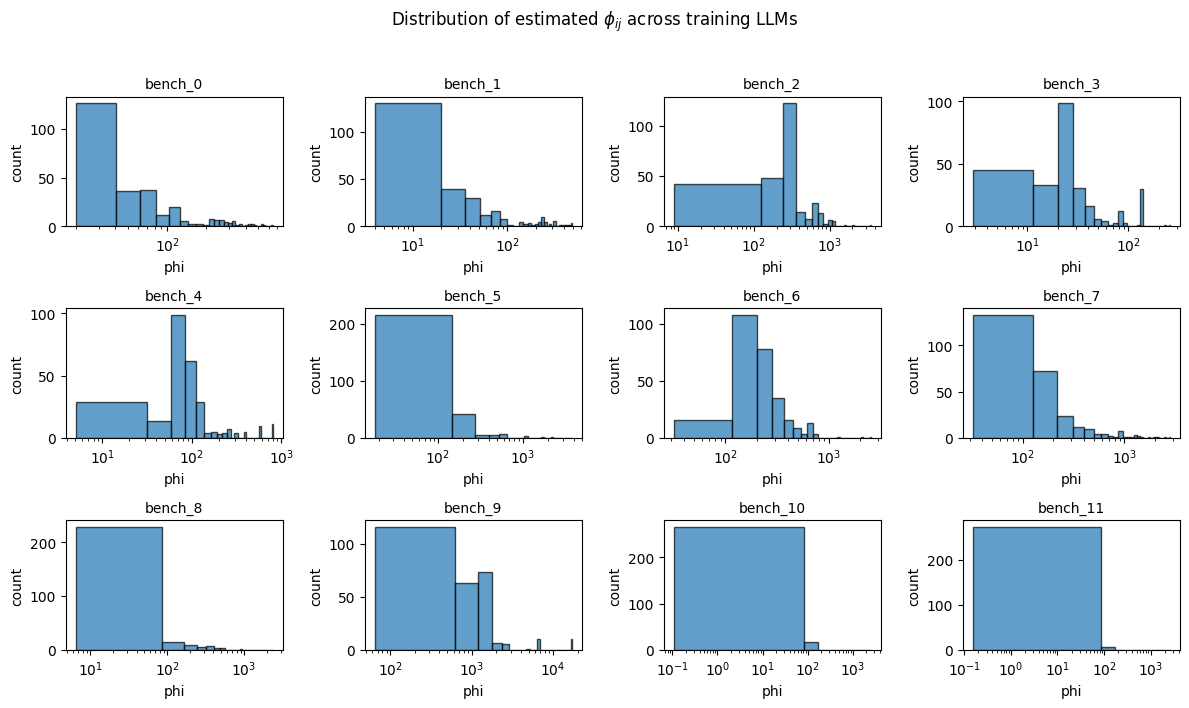

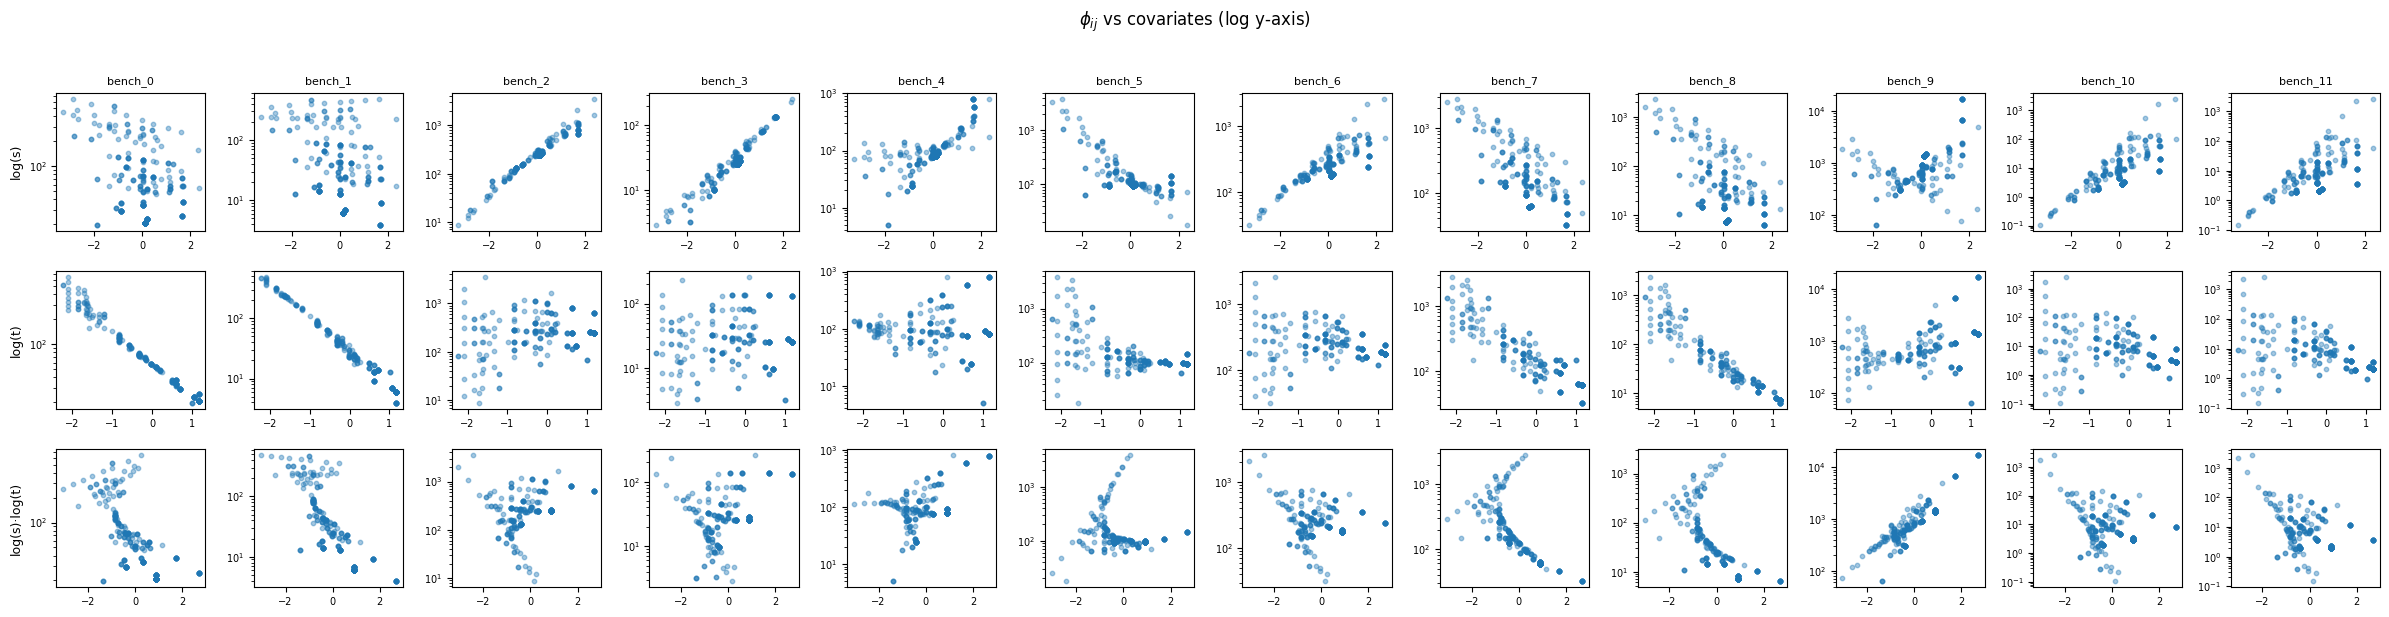


phi_int (one per benchmark):
[4.081 3.328 5.491 3.334 4.552 4.846 5.461 4.998 3.431 6.758 1.984 1.857]

phi_slope (rows = covariates, cols = benchmarks):
[[-0.081 -0.067  0.938  0.87   0.547 -0.575  0.617 -0.461 -0.44   0.133
   1.485  1.361]
 [-1.011 -1.152  0.119 -0.32  -0.815 -0.751 -0.04  -0.771 -1.433 -0.591
  -0.437 -0.488]
 [ 0.169 -0.182 -0.273  0.173  0.798  0.734 -0.36   0.055  0.316  1.28
  -0.693 -0.846]]


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Compute phi_ij for every training LLM ----
X_np      = np.asarray(Xs[j][:, :3])              # match the X you fitted with
phi_int   = np.asarray(quad_models2.phi_int)       # shape (J,)
phi_slope = np.asarray(quad_models2.phi_slope)     # shape (p, J)

log_phi_ij = X_np @ phi_slope + phi_int           # (n, J)
phi_ij     = np.exp(log_phi_ij)                   # (n, J)

n, J = phi_ij.shape
p    = X_np.shape[1]

# Optional: replace with your benchmark name list
bench_names     = [f"bench_{k}" for k in range(J)]
covariate_names = ['log(s)', 'log(t)', 'log(s)·log(t)'][:p]

# ---- 2. Summary table ----
print(f"{'benchmark':<15} {'min':>10} {'q25':>10} {'median':>10} {'q75':>10} {'max':>10}")
for k in range(J):
    pk = phi_ij[:, k]
    print(f"{bench_names[k]:<15} "
          f"{pk.min():>10.3f} {np.quantile(pk, .25):>10.3f} "
          f"{np.median(pk):>10.3f} {np.quantile(pk, .75):>10.3f} "
          f"{pk.max():>10.3f}")

# ---- 3. Histogram of phi per benchmark (log x-axis since phi spans orders of magnitude) ----
n_cols = 4
n_rows = int(np.ceil(J / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.3*n_rows))
axes = np.atleast_1d(axes).flatten()
for k in range(J):
    axes[k].hist(phi_ij[:, k], bins=30, edgecolor='black', alpha=0.7)
    axes[k].set_xscale('log')
    axes[k].set_title(bench_names[k], fontsize=10)
    axes[k].set_xlabel('phi'); axes[k].set_ylabel('count')
for k in range(J, len(axes)):
    axes[k].set_visible(False)
plt.suptitle('Distribution of estimated $\\phi_{ij}$ across training LLMs', y=1.02)
plt.tight_layout(); plt.show()

# ---- 4. phi vs each covariate ----
fig, axes = plt.subplots(p, J, figsize=(2*J, 2*p), squeeze=False)
for c in range(p):
    for k in range(J):
        ax = axes[c, k]
        ax.scatter(X_np[:, c], phi_ij[:, k], s=10, alpha=0.4)
        ax.set_yscale('log')
        if c == 0:           ax.set_title(bench_names[k], fontsize=8)
        if k == 0:           ax.set_ylabel(covariate_names[c], fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('$\\phi_{ij}$ vs covariates (log y-axis)', y=1.02)
plt.tight_layout(); plt.show()

# ---- 5. Inspect the fitted coefficients directly ----
print("\nphi_int (one per benchmark):")
print(np.round(phi_int, 3))
print("\nphi_slope (rows = covariates, cols = benchmarks):")
print(np.round(phi_slope, 3))

model                                           bench_0   bench_1   bench_2   bench_3   bench_4   bench_5   bench_6   bench_7   bench_8   bench_9  bench_10  bench_11
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
[meta-llama-3]
  meta-llama-3-70b                               24.943     3.948   644.633   132.791   789.154   145.683   239.585    32.079     6.439 17079.677     8.123     3.623
  meta-llama-3-70b-instruct                      24.943     3.948   644.633   132.791   789.154   145.683   239.585    32.079     6.439 17079.677     8.123     3.623
[qwen2]
  qwen2-72b                                      37.269     9.014   802.903   136.520   577.729   107.096   352.943    46.485    10.498  6813.843    21.111    11.227
[yi-1.5]
  yi-1.5-34b                                     53.305    20.976   633.033    81.727   250.316    88.744   398.201    82.759    18.969  1

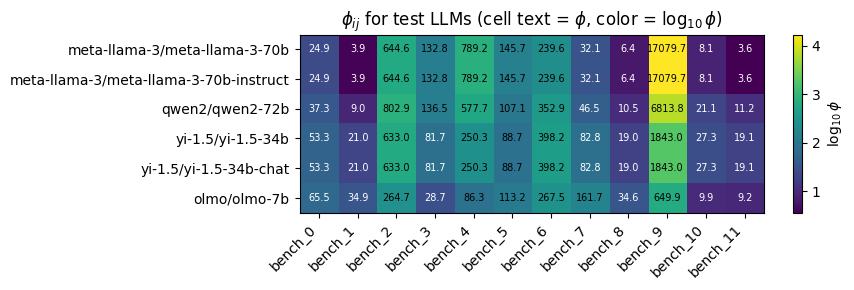

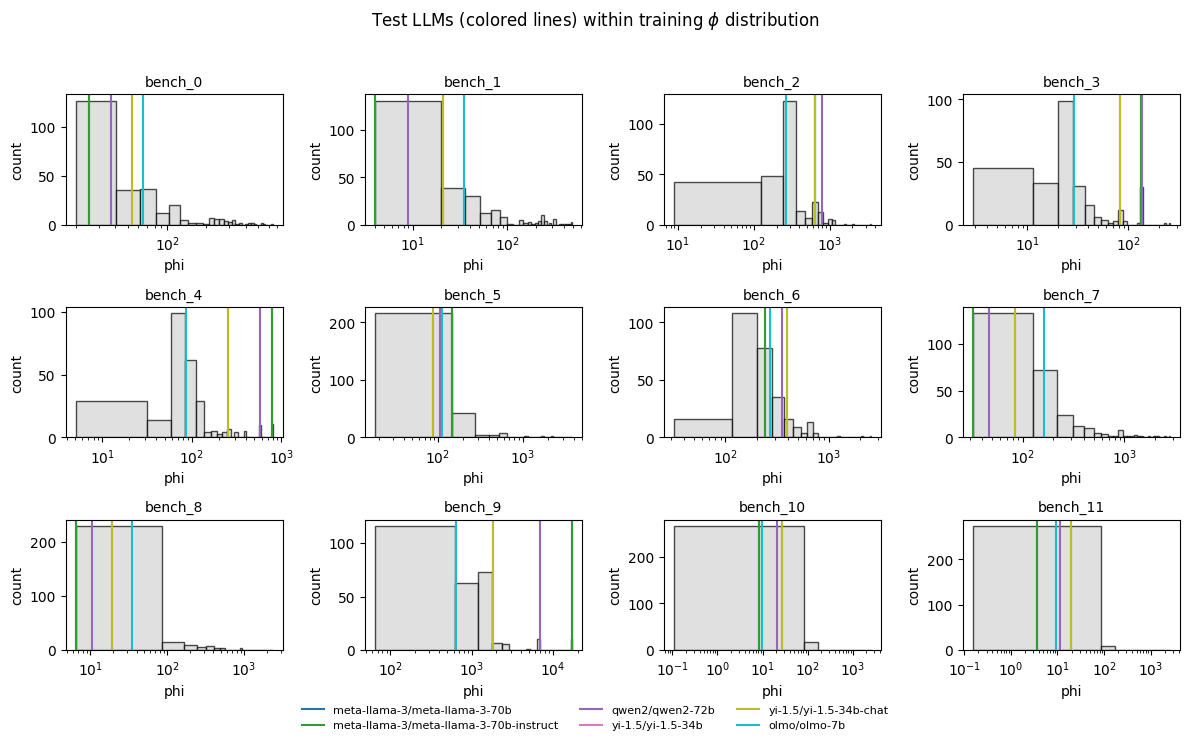

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Compute phi_ij for every training LLM ----
X_np      = np.asarray(Xs[j][:, :3])
phi_int   = np.asarray(quad_models2.phi_int)       # shape (J,)
phi_slope = np.asarray(quad_models2.phi_slope)     # shape (p, J)

log_phi_ij = X_np @ phi_slope + phi_int            # (n, J)
phi_ij     = np.exp(log_phi_ij)                    # (n, J)

n, J = phi_ij.shape
p    = X_np.shape[1]

bench_names     = [f"bench_{k}" for k in range(J)]   # replace with real names if you have them
covariate_names = ['log(s)', 'log(t)', 'log(s)·log(t)'][:p]

# ---- 2. Locate the test LLMs in the training matrix ----
test_models = {'meta-llama-3':['meta-llama-3-70b', 'meta-llama-3-70b-instruct'],
               'qwen2'       :['qwen2-72b'],
               'yi-1.5'      :['yi-1.5-34b', 'yi-1.5-34b-chat'],
               'olmo'        :['olmo-7b']}

model_names = dfs[0]['model'].values

test_rows = []   # list of (family, model_name, row_index)
for family, models in test_models.items():
    for m in models:
        hits = np.where(model_names == m)[0]
        if len(hits) == 0:
            print(f"  [warn] {m} not found in df[0].model")
            continue
        test_rows.append((family, m, int(hits[0])))

test_idx    = [r[2] for r in test_rows]
test_labels = [f"{r[0]}/{r[1]}" for r in test_rows]
phi_test    = phi_ij[test_idx]                    # (n_test, J)

# ---- 3. Printed table (grouped by family) ----
print(f"{'model':<45}" + "".join(f"{bn:>10}" for bn in bench_names))
print("-" * (45 + 10*J))
current_family = None
for (family, m, idx), row in zip(test_rows, phi_test):
    if family != current_family:
        print(f"[{family}]")
        current_family = family
    print(f"  {m:<43}" + "".join(f"{v:>10.3f}" for v in row))

# ---- 4. Heatmap of phi values for the test LLMs ----
fig, ax = plt.subplots(figsize=(max(8, J*0.75), max(3, len(test_labels)*0.45)))
im = ax.imshow(np.log10(phi_test), aspect='auto', cmap='viridis')
ax.set_xticks(range(J)); ax.set_xticklabels(bench_names, rotation=45, ha='right')
ax.set_yticks(range(len(test_labels))); ax.set_yticklabels(test_labels)
ax.set_title(r'$\phi_{ij}$ for test LLMs (cell text = $\phi$, color = $\log_{10}\phi$)')
plt.colorbar(im, ax=ax, label=r'$\log_{10}\phi$')
for i in range(len(test_labels)):
    for k in range(J):
        ax.text(k, i, f"{phi_test[i, k]:.1f}",
                ha='center', va='center',
                color='white' if np.log10(phi_test[i, k]) < np.log10(phi_test).mean() else 'black',
                fontsize=7)
plt.tight_layout(); plt.show()

# ---- 5. Where each test LLM falls in the training phi distribution ----
n_cols = 4
n_rows = int(np.ceil(J / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.3*n_rows))
axes = np.atleast_1d(axes).flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(test_labels)))
for k in range(J):
    ax = axes[k]
    ax.hist(phi_ij[:, k], bins=30, color='lightgray', edgecolor='black', alpha=0.7)
    ax.set_xscale('log')
    ax.set_title(bench_names[k], fontsize=10)
    ax.set_xlabel('phi'); ax.set_ylabel('count')
    for li, v in enumerate(phi_test[:, k]):
        ax.axvline(v, color=colors[li], linewidth=1.5)
for k in range(J, len(axes)):
    axes[k].set_visible(False)

handles = [plt.Line2D([0], [0], color=c, label=l) for c, l in zip(colors, test_labels)]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=3, fontsize=8, frameon=False)
plt.suptitle(r'Test LLMs (colored lines) within training $\phi$ distribution', y=1.02)
plt.tight_layout(); plt.show()

In [45]:
models[0]

'olmo-7b'

In [46]:
model[K].phi

array([[ 70.18848  ,  34.313164 , 197.97186  ,  17.222683 ,  61.351025 ,
        136.63345  , 234.66556  , 139.94353  ,  40.147594 , 499.91205  ,
          3.814393 ,   3.1671302]], dtype=float32)

In [35]:
j=0
quad_models = ScalingLaw(K)
quad_models.fit(Xs[j][:,:3],
                  Ys[j],
                  Ds[j],
                  Cs[j],
                  B = B,
                  lrs = [.1],
                  scheduler_factors = [.999],
                  reps = 1,
                  n_epochs = 20000,    
                  verbose = True,
                  device = 'cuda')

Different lrs:   0%|          | 0/1 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/1 [00:00<?, ?it/s]

Reps:   0%|          | 0/1 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

epoch= 1000, B=10000, grad=0.12734, loss=-0.94159, lr=0.09792
 grads: {'L': 0.024349024519324303, 'lambd1': 0.06745047867298126, 'lambd2': 0.09535402804613113, 'phi_int': 0.0027723265811800957, 'phi_slope': 0.004893612582236528, 'b': 0.03156210854649544, 'beta': 0.030863916501402855}
epoch= 2000, B=10000, grad=0.11611, loss=-0.94275, lr=0.09484
 grads: {'L': 0.04160873964428902, 'lambd1': 0.050729844719171524, 'lambd2': 0.06769060343503952, 'phi_int': 0.0029421686194837093, 'phi_slope': 0.006049100309610367, 'b': 0.0629332885146141, 'beta': 0.024283813312649727}
epoch= 3000, B=10000, grad=0.20730, loss=-0.94179, lr=0.09185
 grads: {'L': 0.03967282548546791, 'lambd1': 0.05228724330663681, 'lambd2': 0.18611258268356323, 'phi_int': 0.0026316214352846146, 'phi_slope': 0.006588286720216274, 'b': 0.04523301124572754, 'beta': 0.04393476992845535}
epoch= 4000, B=10000, grad=0.21305, loss=-0.94074, lr=0.08895
 grads: {'L': 0.025708969682455063, 'lambd1': 0.09464924037456512, 'lambd2': 0.1755379

In [37]:
quad_models.configs

{'random_seed': [0],
 'lr': [0.1],
 'scheduler_factor': [0.999],
 'loglike': [3246.92431640625]}

benchmark              min        q25     median        q75        max
bench_0             28.900     42.798     76.367    147.492    899.525
bench_1              1.775      4.860      8.535     10.720     93.689
bench_2             22.895    141.682    288.102    375.021   2800.451
bench_3              3.054     19.010     26.617     44.711    274.850
bench_4              5.239     76.813     87.168    115.489    808.745
bench_5             16.202    108.508    117.048    145.184   5846.290
bench_6             58.405    201.388    262.606    359.767   1246.855
bench_7              9.772     73.029     98.278    157.416   2712.288
bench_8              7.998     12.004     22.890     70.459   2266.959
bench_9             74.671    457.693    835.553   1328.149  14021.959
bench_10             0.112      2.816      5.883     19.166   2365.730
bench_11             0.138      1.995      4.409     14.605   2963.248


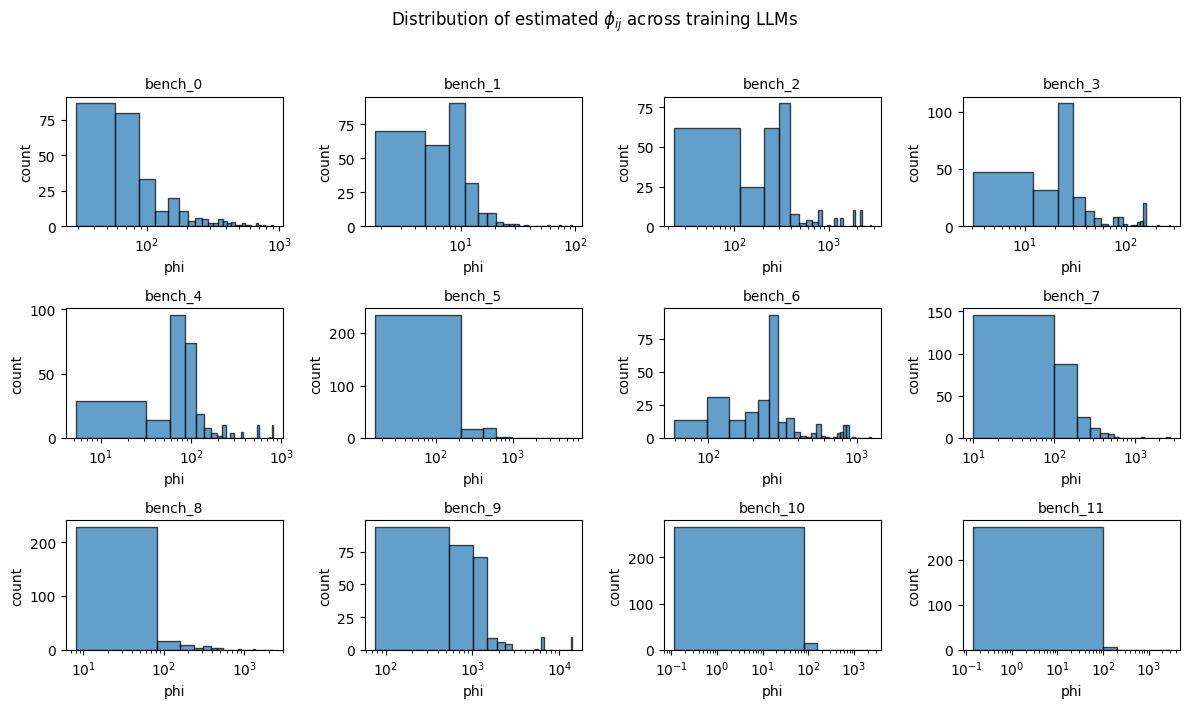

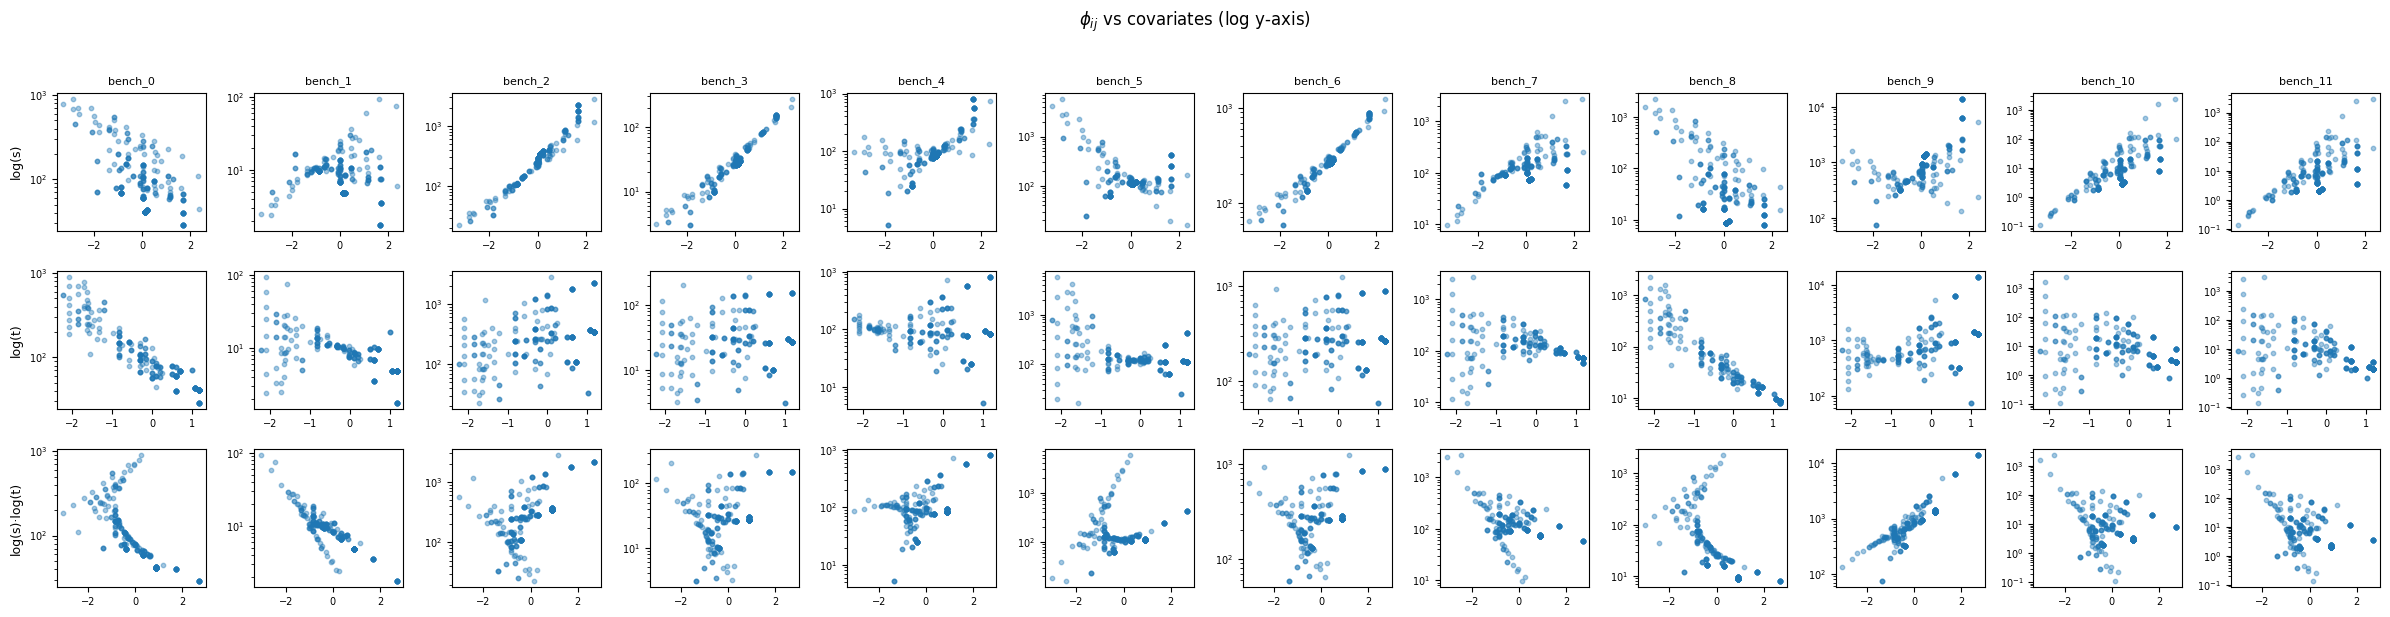


phi_int (one per benchmark):
[4.491 2.072 5.621 3.361 4.557 4.95  5.602 4.738 3.504 6.774 1.976 1.863]

phi_slope (rows = covariates, cols = benchmarks):
[[-0.3    0.248  0.84   0.859  0.475 -0.441  0.567  0.673 -0.444  0.248
   1.467  1.386]
 [-0.686  0.135 -0.128 -0.329 -0.832 -1.037 -0.224  0.087 -1.367 -0.499
  -0.433 -0.48 ]
 [ 0.067 -0.768  0.3    0.225  0.858  1.131  0.182 -0.709  0.342  1.09
  -0.688 -0.874]]


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Compute phi_ij for every training LLM ----
X_np      = np.asarray(Xs[j][:, :3])              # match the X you fitted with
phi_int   = np.asarray(quad_models.phi_int)       # shape (J,)
phi_slope = np.asarray(quad_models.phi_slope)     # shape (p, J)

log_phi_ij = X_np @ phi_slope + phi_int           # (n, J)
phi_ij     = np.exp(log_phi_ij)                   # (n, J)

n, J = phi_ij.shape
p    = X_np.shape[1]

# Optional: replace with your benchmark name list
bench_names     = [f"bench_{k}" for k in range(J)]
covariate_names = ['log(s)', 'log(t)', 'log(s)·log(t)'][:p]

# ---- 2. Summary table ----
print(f"{'benchmark':<15} {'min':>10} {'q25':>10} {'median':>10} {'q75':>10} {'max':>10}")
for k in range(J):
    pk = phi_ij[:, k]
    print(f"{bench_names[k]:<15} "
          f"{pk.min():>10.3f} {np.quantile(pk, .25):>10.3f} "
          f"{np.median(pk):>10.3f} {np.quantile(pk, .75):>10.3f} "
          f"{pk.max():>10.3f}")

# ---- 3. Histogram of phi per benchmark (log x-axis since phi spans orders of magnitude) ----
n_cols = 4
n_rows = int(np.ceil(J / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.3*n_rows))
axes = np.atleast_1d(axes).flatten()
for k in range(J):
    axes[k].hist(phi_ij[:, k], bins=30, edgecolor='black', alpha=0.7)
    axes[k].set_xscale('log')
    axes[k].set_title(bench_names[k], fontsize=10)
    axes[k].set_xlabel('phi'); axes[k].set_ylabel('count')
for k in range(J, len(axes)):
    axes[k].set_visible(False)
plt.suptitle('Distribution of estimated $\\phi_{ij}$ across training LLMs', y=1.02)
plt.tight_layout(); plt.show()

# ---- 4. phi vs each covariate ----
fig, axes = plt.subplots(p, J, figsize=(2*J, 2*p), squeeze=False)
for c in range(p):
    for k in range(J):
        ax = axes[c, k]
        ax.scatter(X_np[:, c], phi_ij[:, k], s=10, alpha=0.4)
        ax.set_yscale('log')
        if c == 0:           ax.set_title(bench_names[k], fontsize=8)
        if k == 0:           ax.set_ylabel(covariate_names[c], fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('$\\phi_{ij}$ vs covariates (log y-axis)', y=1.02)
plt.tight_layout(); plt.show()

# ---- 5. Inspect the fitted coefficients directly ----
print("\nphi_int (one per benchmark):")
print(np.round(phi_int, 3))
print("\nphi_slope (rows = covariates, cols = benchmarks):")
print(np.round(phi_slope, 3))

In [38]:
model[K].phi

array([[ 70.18848  ,  34.313164 , 197.97186  ,  17.222683 ,  61.351025 ,
        136.63345  , 234.66556  , 139.94353  ,  40.147594 , 499.91205  ,
          3.814393 ,   3.1671302]], dtype=float32)

In [18]:
model[K].phi

array([[ 70.18848  ,  34.313164 , 197.97186  ,  17.222683 ,  61.351025 ,
        136.63345  , 234.66556  , 139.94353  ,  40.147594 , 499.91205  ,
          3.814393 ,   3.1671302]], dtype=float32)

In [22]:
Xs[0]

array([[ 0.20765218,  1.06744839,  0.89367909, -0.13520078,  1.29654127],
       [ 0.12311635,  1.17319053,  0.89228263, -0.22557546,  1.57668004],
       [ 2.34163488, -1.5706003 , -2.44004551,  3.79508316, -0.7708693 ],
       ...,
       [-0.08336027, -0.01607859, -0.23492192, -0.42538546, -0.69785113],
       [ 0.20765218,  0.15859722,  0.06200564, -0.13520078, -0.48427548],
       [ 0.02727753,  0.49611174,  0.23228294, -0.32201295,  0.04594251]],
      shape=(286, 5))

In [47]:
# Standard library imports
import numpy as np

# Third-party imports
import torch
from torch import nn
from torch.nn import Parameter
from torch.distributions import Beta, MultivariateNormal, Normal
from torch.optim import Adam, LBFGS
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR
from torch.autograd.functional import hessian, jacobian
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

# Aliases / constants
sigmoid = torch.sigmoid

def ch(x: torch.Tensor, tril: bool = True) -> torch.Tensor:
    """
    Build a lower-triangular matrix (or its product) from a flattened tensor.
    """
    n = int((2 * len(x)) ** 0.5)
    if (n * (n + 1)) // 2 != len(x):
        raise ValueError("Length of x is not suitable to fill a lower triangular matrix")

    result = torch.zeros((n, n), dtype=x.dtype, device=x.device)
    row_idx, col_idx = torch.tril_indices(n, n)
    result[row_idx, col_idx] = x

    return result if tril else result @ result.T

def log_like(
    X_mean: torch.Tensor,
    X_phi: torch.Tensor,
    Y: torch.Tensor,
    D: torch.Tensor,
    C: torch.Tensor,
    beta: torch.Tensor,
    lambd: torch.Tensor,
    b: torch.Tensor,
    phi_int: torch.Tensor,
    phi_slope: torch.Tensor,
    L: torch.Tensor,
    K: int,
    Z: torch.Tensor = None,
    B: int = 100000,
    eps: float = 1e-6,
    device: str = 'cpu',
    random_seed = 42,
    agg=True
) -> torch.Tensor:
    """
    Compute the Monte Carlo log-likelihood under the specified model.
    The mean uses X_mean with covariate matrix beta of shape (p_mean, K).
    Dispersion is parameterized as phi_ij = exp(x_phi_i^T phi_slope_j + phi_int_j),
    where phi_slope has shape (p_phi, J).
    """
    if Z is not None:
        B = Z.shape[0]
    else:
        torch.manual_seed(random_seed)
        norm_dist = MultivariateNormal(torch.zeros(K), torch.eye(K))
        Z = norm_dist.sample(sample_shape=(B,)).to(device)

    A = Z @ ch(L).T
    logits = (X_mean @ beta)[None, :, :] + A[:, None, :]
    logits = logits @ lambd + b[None, :]

    mu = C[None, :] + (1 - C[None, :]) * sigmoid(logits)
    mu = mu.clamp(min=eps, max=1.0 - eps)

    # Heteroscedastic dispersion: phi_ij = exp(x_phi_i^T phi_slope_j + phi_int_j)
    # phi_int:   shape (J,)
    # phi_slope: shape (p_phi, J)
    # X_phi:     shape (n, p_phi)
    log_phi = X_phi @ phi_slope + phi_int         # (n, J)
    phi_ij  = torch.exp(log_phi).clamp(max=1e6)   # (n, J), cap for numerical safety
    beta_dist = Beta(phi_ij[None, :, :] * mu,
                     phi_ij[None, :, :] * (1 - mu))

    nan_mask = torch.isnan(Y) #dealing with missing values
    Y_clipped = torch.where(nan_mask, torch.full_like(Y, 0.5), Y)
    ll_terms = beta_dist.log_prob(Y_clipped[None, :])
    ll_terms = torch.where(nan_mask, torch.zeros_like(ll_terms), ll_terms).sum(-1)

    loglike = (
        torch.logsumexp(ll_terms @ D, dim=0)
        - np.log(B)
    )
    if agg:
        return loglike.sum()
    else:
        return loglike

def fit_model(
    X_mean: torch.Tensor,
    X_phi: torch.Tensor,
    Y: torch.Tensor,
    D: torch.Tensor,
    C: torch.Tensor,
    K: int = 3,
    L: torch.Tensor = None,
    beta: torch.Tensor = None,
    b: torch.Tensor = None,
    phi_int: torch.Tensor = None,
    phi_slope: torch.Tensor = None,
    lambd1: torch.Tensor = None,
    lambd2: torch.Tensor = None,
    B: int = 1000,              # initial MC samples
    B_frequency: int = 1,
    max_hist_params = 99999,
    frac_hist_params = .2,
    lr: float = 1e-2,
    scheduler_factor: float = .9,    # reduction factor on plateau
    scheduler_patience: int = 30,     # epochs with no improvement before reducing
    scheduler_threshold: float = 1e-3,
    n_epochs: int = 10000,
    print_every: int = 1000,
    scale: float = 1.,
    tol: float = 1e-3,
    verbose: bool = True,
    device: str = 'cpu',
    random_seed: int = 42,
) -> dict:
    """
    Fit the mixed-effects model via stochastic optimization.
    Returns history, AIC, best parameters, and convergence flag.
    The mean uses X_mean (shape (n, p_mean)) and the dispersion uses X_phi
    (shape (n, p_phi)). Dispersion is phi_ij = exp(x_phi_i^T phi_slope_j + phi_int_j).
    """
    torch.manual_seed(random_seed)

    N      = D.shape[1]
    p_mean = X_mean.shape[1]
    p_phi  = X_phi.shape[1]
    J      = Y.shape[1]

    # Helper for random initialization
    def _rand(shape, func, abs_val=False):
        t = func(0, scale, size=shape, device=device)
        return torch.abs(t) if abs_val else t

    # Initialize or perturb parameters
    L_rand         = _rand(((K * (K + 1)) // 2,), torch.normal)
    beta_rand      = _rand((p_mean, K), torch.normal)
    b_rand         = _rand((1, J), torch.normal)
    phi_int_rand   = _rand((J,),    torch.normal)             # unconstrained (log-scale)
    phi_slope_rand = _rand((p_phi, J), torch.normal) * 0.01   # near-zero => warm start near homoscedastic
    l1_rand        = _rand((K,), torch.normal, abs_val=True)
    l2_rand        = _rand((K, J - K), torch.normal)

    def _init(param, rand):
        if param is None:
            return Parameter(rand)
        data = param.cpu().detach().numpy() + rand.cpu().detach().numpy()
        return Parameter(torch.tensor(data, device=device))

    L         = _init(L,         L_rand)
    beta      = _init(beta,      beta_rand)
    b         = _init(b,         b_rand)
    phi_int   = _init(phi_int,   phi_int_rand)
    phi_slope = _init(phi_slope, phi_slope_rand)
    lambd1    = _init(lambd1,    l1_rand)
    lambd2    = _init(lambd2,    l2_rand)

    # Optimizer setup
    parameters = [L, lambd1, lambd2, phi_int, phi_slope, b, beta]
    optimizer  = Adam(parameters, lr=lr)
    scheduler  = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        threshold=scheduler_threshold,
        threshold_mode='abs'
    )

    hist = []
    hist_params = []

    for ep in tqdm(range(n_epochs), desc="Training ME model", disable=not verbose):
        # Resample Z periodically
        if ep % B_frequency == 0:
            norm_dist = MultivariateNormal(torch.zeros(K), torch.eye(K))
            Z = norm_dist.sample(sample_shape=(B,)).to(device)

            # Keeping track
            current_params = {
                'L':         L.detach().cpu().clone(),
                'lambd1':    lambd1.detach().cpu().clone(),
                'lambd2':    lambd2.detach().cpu().clone(),
                'phi_int':   phi_int.detach().cpu().clone(),
                'phi_slope': phi_slope.detach().cpu().clone(),
                'b':         b.detach().cpu().clone(),
                'beta':      beta.detach().cpu().clone(),
            }
            hist_params.append(current_params)
            if len(hist_params)>max_hist_params:
                hist_params = hist_params[-max_hist_params:]

        # Build full lambda matrix
        lambd = torch.hstack((torch.diag(lambd1), lambd2))

        optimizer.zero_grad()
        loss = -log_like(
            X_mean=X_mean, X_phi=X_phi, Y=Y, D=D, C=C,
            beta=beta, lambd=lambd,
            b=b, phi_int=phi_int, phi_slope=phi_slope,
            L=L, K=K,
            Z=Z, device=device
        )
        loss /= (Y.shape[0] * Y.shape[1])
        hist.append(loss.item())

        # Backprop
        loss.backward()

        # Compute gradient norm
        total_grad = torch.sqrt(sum((p.grad**2).sum() for p in parameters)).item()
        grad_info = {name: torch.norm(param.grad).item()
                     for name, param in zip(
                         ['L','lambd1','lambd2','phi_int','phi_slope','b','beta'], parameters)}

        # Logging
        if verbose and ((ep+1) % print_every == 0):
            lr_now = scheduler.get_last_lr()[0]
            print(f"epoch={ep+1:5d}, B={B:5d}, grad={total_grad:.5f}, "
                  f"loss={loss.item():.5f}, lr={lr_now:.5f}")
            print(" grads:", grad_info)

        optimizer.step()
        scheduler.step(loss.item())

        # Projection step
        with torch.no_grad():
            # Keep L lower-triangular with unit row norms
            L.data = ch(L.data, tril=True)
            row_norms = L.data.norm(dim=1, keepdim=True)
            L.data = L.data / row_norms              # still full matrix
            L.data = L.data[torch.tril(torch.ones_like(L)).bool()]

            # phi positivity is guaranteed by exp() - no clamp needed
            lambd1.clamp_(min=0)

    # Finalize best parameters
    n_avg = int(frac_hist_params*len(hist_params))
    avg_params = {}
    for key in hist_params[-1]:
        avg_params[key] = [d[key].numpy() for d in hist_params[-n_avg:]]
        avg_params[key] = torch.tensor(np.mean(np.array(avg_params[key]),0))

    avg_params['lambd'] = torch.hstack((torch.diag(avg_params['lambd1']), avg_params['lambd2']))

    # Compute AIC, loglike, and grad
    device = 'cpu'

    n_params = int(K*(K-1)/2 +
                   sum(int(np.prod(avg_params[p].shape))
                       for p in ['beta','lambd1','lambd2','b','phi_int','phi_slope']))

    beta      = avg_params['beta'].clone().detach().requires_grad_(True)
    lambd1    = avg_params['lambd1'].clone().detach().requires_grad_(True)
    lambd2    = avg_params['lambd2'].clone().detach().requires_grad_(True)
    b         = avg_params['b'].clone().detach().requires_grad_(True)
    phi_int   = avg_params['phi_int'].clone().detach().requires_grad_(True)
    phi_slope = avg_params['phi_slope'].clone().detach().requires_grad_(True)
    L         = avg_params['L'].clone().detach().requires_grad_(True)
    lambd     = torch.hstack((torch.diag(lambd1), lambd2))

    ll = log_like(
        X_mean=X_mean.to(device), X_phi=X_phi.to(device),
        Y=Y.to(device), D=D.to(device), C=C.to(device),
        beta=beta.to(device),
        lambd=lambd.to(device),
        b=b.to(device),
        phi_int=phi_int.to(device),
        phi_slope=phi_slope.to(device),
        L=L.to(device),
        K=K, device=device)

    ll.backward()

    cte = int(Y.shape[0]*Y.shape[1])
    grad_norm = {}
    grad_norm['beta']      = beta.grad.norm()/cte
    grad_norm['lambd1']    = lambd1.grad.norm()/cte
    grad_norm['lambd2']    = lambd2.grad.norm()/cte
    grad_norm['b']         = b.grad.norm()/cte
    grad_norm['phi_int']   = phi_int.grad.norm()/cte
    grad_norm['phi_slope'] = phi_slope.grad.norm()/cte
    grad_norm['L']         = L.grad.norm()/cte
    grad_norm['total']     = (beta.grad.norm()**2
                              + lambd1.grad.norm()**2
                              + lambd2.grad.norm()**2
                              + b.grad.norm()**2
                              + phi_int.grad.norm()**2
                              + phi_slope.grad.norm()**2
                              + L.grad.norm()**2)**.5 / cte

    print("final grad norm:", grad_norm['total'].item())

    aic = -2 * (ll.item() - n_params)

    return {
        'hist': hist,
        'loglike': ll.item(),
        'aic': aic,
        #'hist_params': hist_params,
        'grad_norm': grad_norm,
        **avg_params
    }

class ScalingLaw:
    def __init__(self, K):
        self.K = K
        self.L = None
        self.beta = None
        self.b = None
        self.phi_int = None
        self.phi_slope = None
        self.lambd1 = None
        self.lambd2 = None

    def fit(self,
              X_mean,
              Y,
              D,
              C,
              X_phi = None,                 # if None, defaults to X_mean
              fe_start = False,
              reps = 10,
              B = 5000, #initial MC samples
              B_frequency = 1,
              lrs = [.05,.01,.005],
              scheduler_factors = [.99],  # Decay factor for line search learning rate
              n_epochs = 20000,
              lr_fe = .1,
              scheduler_factor_fe = .9999,
              n_epochs_fe = 15000,
              scale = 1,
              tol = 1e-4,
              print_every = 1000,
              verbose = True,
              device='cpu'):

        X_mean = torch.tensor(X_mean).float().to(device)
        if X_phi is None:
            X_phi = X_mean
        else:
            X_phi = torch.tensor(X_phi).float().to(device)
        Y = torch.tensor(Y).float().to(device)
        D = torch.tensor(D).float().to(device)
        C = torch.tensor(C).float().to(device)

        outs = []
        configs = {'random_seed':[], 'lr':[], 'scheduler_factor':[], 'loglike':[]}
        r=0
        for lr in tqdm(lrs, desc="Different lrs"):
            for scheduler_factor in tqdm(scheduler_factors, desc="Different scheduler factors"):
                for _ in tqdm(range(reps), desc="Reps"):
                    outs.append(fit_model(X_mean,
                                          X_phi,
                                          Y,
                                          D,
                                          C,
                                          K = self.K,
                                          L = self.L,
                                          beta = self.beta,
                                          b = self.b,
                                          phi_int = self.phi_int,
                                          phi_slope = self.phi_slope,
                                          lambd1 = self.lambd1,
                                          lambd2 = self.lambd2,
                                          B = B, #initial MC samples
                                          lr = lr,
                                          scheduler_factor = scheduler_factor,
                                          n_epochs = n_epochs,
                                          scale = scale,
                                          tol = tol,
                                          verbose = verbose,
                                          print_every = print_every,
                                          device = device,
                                          random_seed = r))
                    configs['loglike'].append(outs[-1]['loglike'])
                    configs['random_seed'].append(r)
                    configs['lr'].append(lr)
                    configs['scheduler_factor'].append(scheduler_factor)
                    r+=1

        self.configs = configs
        self.outs = outs
        ind = np.argmax([o['loglike'] for o in self.outs])
        self.loglike   = self.outs[ind]['loglike']
        self.gradnorm  = self.outs[ind]['grad_norm']
        self.aic       = self.outs[ind]['aic']
        self.sigma     = ch(self.outs[ind]['L'], tril=False).cpu().numpy()
        self.L         = self.outs[ind]['L'].cpu().numpy()
        self.lambd     = self.outs[ind]['lambd'].cpu().numpy()
        self.phi_int   = self.outs[ind]['phi_int'].cpu().numpy()
        self.phi_slope = self.outs[ind]['phi_slope'].cpu().numpy()
        self.b         = self.outs[ind]['b'].cpu().numpy()
        self.beta      = self.outs[ind]['beta'].cpu().numpy()

In [51]:
j=0
quad_models = ScalingLaw(K)
quad_models.fit(Xs[j][:,:3],
                  Ys[j],
                  Ds[j],
                  Cs[j],
                  np.hstack((Xs[j][:,:3], Ds[j])),
                  B = B,
                  lrs = [.05],
                  scheduler_factors = [.999],
                  reps = 1,
                  n_epochs = 20000,    
                  verbose = True,
                  device = 'cuda')

Different lrs:   0%|          | 0/1 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/1 [00:00<?, ?it/s]

Reps:   0%|          | 0/1 [00:00<?, ?it/s]

Training ME model:   0%|          | 0/20000 [00:00<?, ?it/s]

epoch= 1000, B=10000, grad=0.61489, loss=-1.32467, lr=0.04916
 grads: {'L': 0.13818590342998505, 'lambd1': 0.10100582242012024, 'lambd2': 0.5522225499153137, 'phi_int': 0.003896925365552306, 'phi_slope': 0.008174835704267025, 'b': 0.18586695194244385, 'beta': 0.09596510231494904}
epoch= 2000, B=10000, grad=0.96888, loss=-1.33230, lr=0.04766
 grads: {'L': 0.26089590787887573, 'lambd1': 0.14113770425319672, 'lambd2': 0.740412712097168, 'phi_int': 0.001313141779974103, 'phi_slope': 0.008119788020849228, 'b': 0.3889080584049225, 'beta': 0.38887280225753784}
epoch= 3000, B=10000, grad=0.58342, loss=-1.31040, lr=0.04615
 grads: {'L': 0.07815882563591003, 'lambd1': 0.238826185464859, 'lambd2': 0.4771842360496521, 'phi_int': 0.003612091299146414, 'phi_slope': 0.005974415689706802, 'b': 0.207882359623909, 'beta': 0.07914315164089203}
epoch= 4000, B=10000, grad=1.19130, loss=-1.33749, lr=0.04479
 grads: {'L': 0.18671059608459473, 'lambd1': 0.23458240926265717, 'lambd2': 1.0375741720199585, 'phi_

In [53]:
quad_models.configs

{'random_seed': [0],
 'lr': [0.05],
 'scheduler_factor': [0.999],
 'loglike': [4717.64990234375]}

benchmark              min        q25     median        q75        max
bench_0              2.197     16.541     37.996    404.307 3942831.039
bench_1              1.291      5.148     14.842     61.816 264796.853
bench_2              0.247      6.388    108.024    897.175 1157667.593
bench_3              1.319     13.553    102.521    806.972 29758209.398
bench_4              1.413     25.893    249.429   5160.398 56228051.307
bench_5              5.083     41.403    181.957   1214.511 504255.780
bench_6              1.526     39.374    155.877    610.674 507651.414
bench_7              2.073     28.626     68.356    393.541 105099.965
bench_8              0.006      0.514     24.526    237.578 130404.339
bench_9              4.275     97.513    274.927   1117.363 438625.594
bench_10             0.578      2.814      6.793    901.828 118675.613
bench_11             0.004      1.623      3.881    371.124 1048505.595


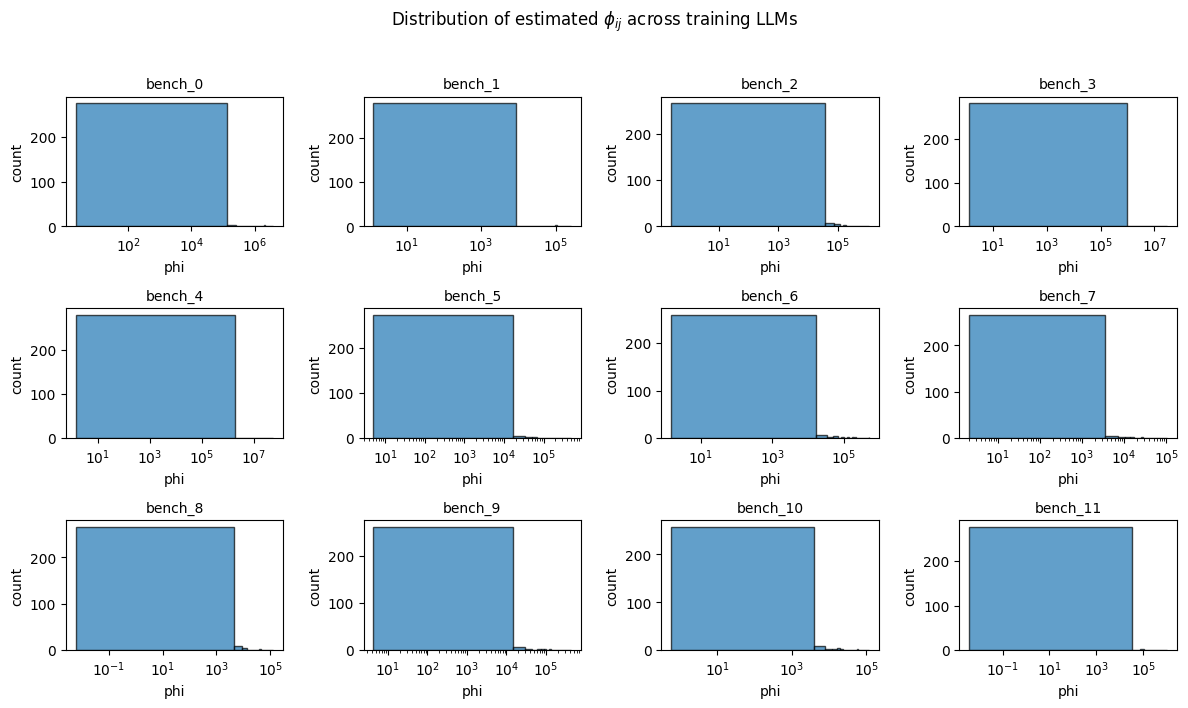

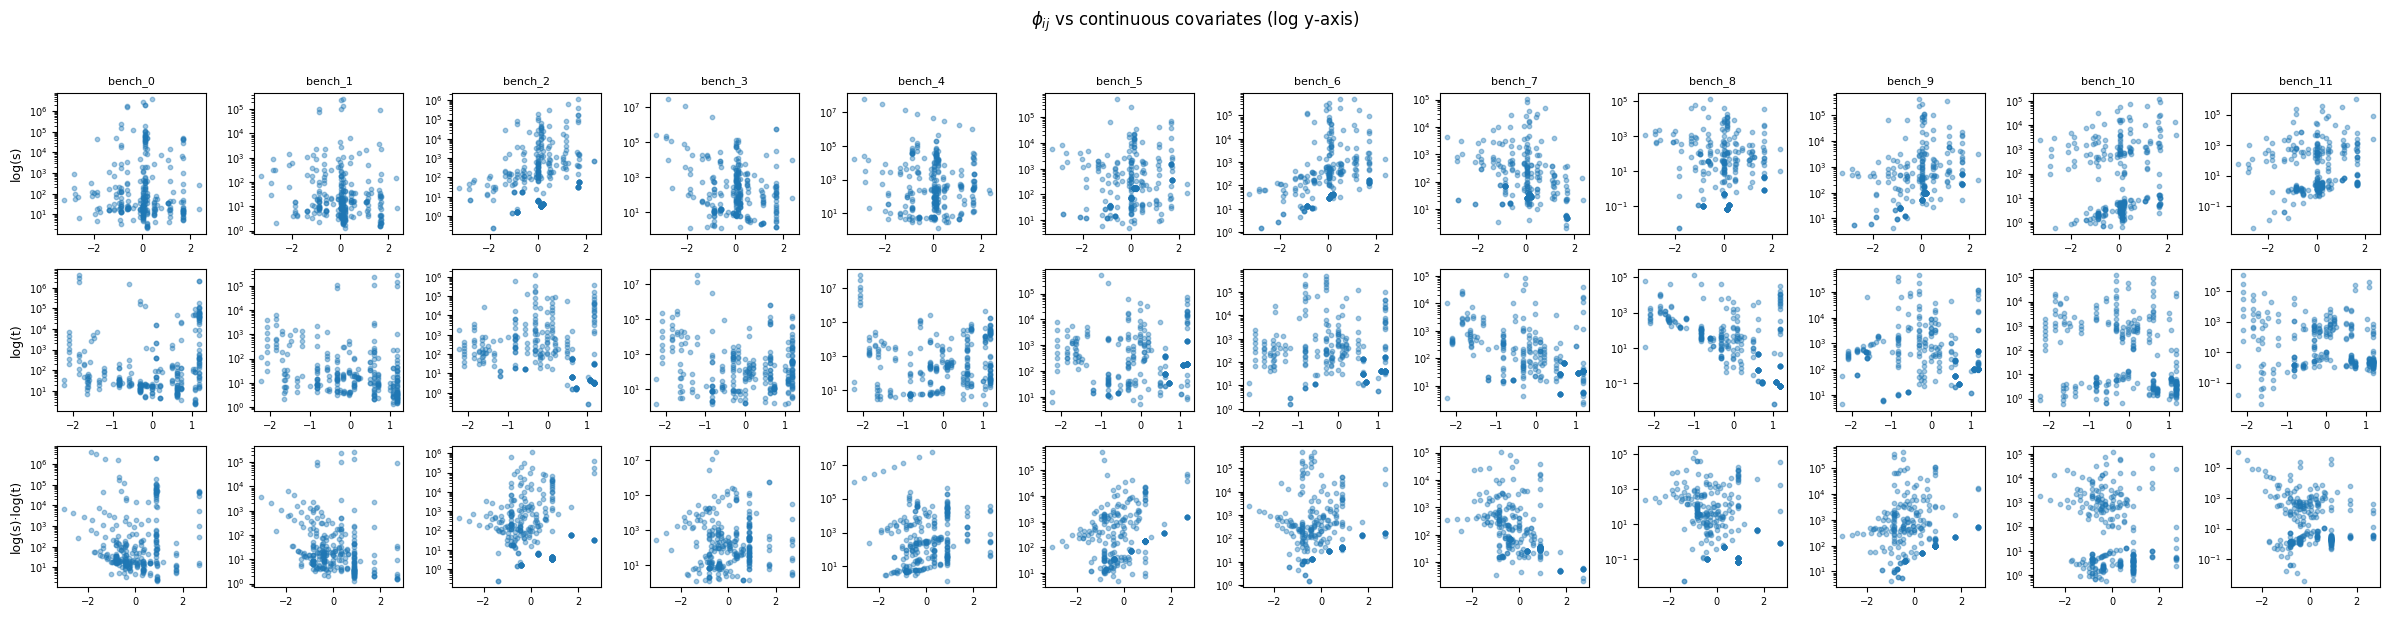

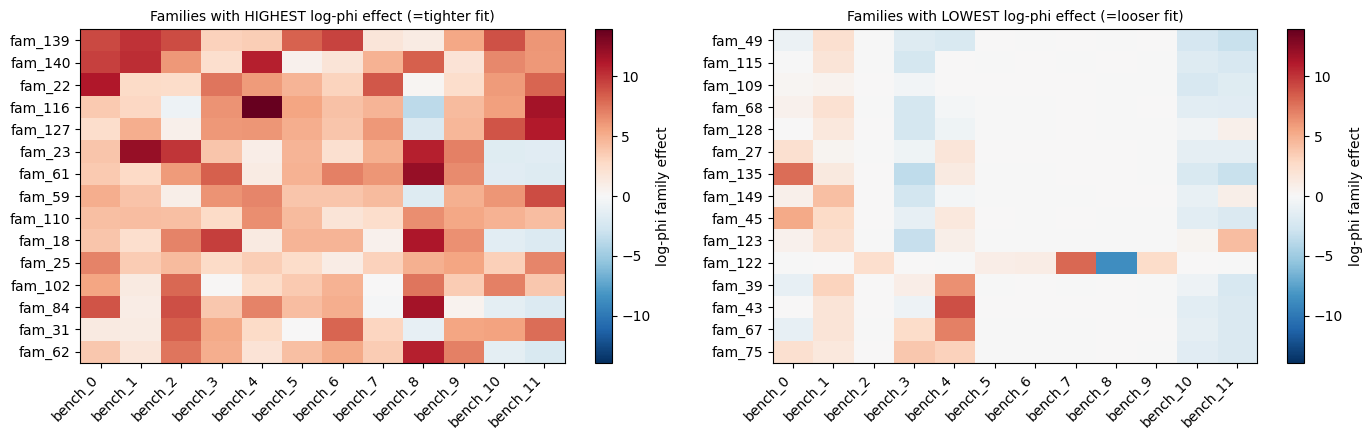


model                                           bench_0   bench_1   bench_2   bench_3   bench_4   bench_5   bench_6   bench_7   bench_8   bench_9  bench_10  bench_11
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
[meta-llama-3]
  meta-llama-3-70b                               16.428     2.444166789.913     4.206   258.128 38922.835   132.025     2.605    59.646 16626.167    31.286   153.094
  meta-llama-3-70b-instruct                    1001.871     1.480 94500.623     3.380   830.989 57927.472 21339.224     6.032  1595.460 17466.290 22514.393   423.891
[qwen2]
  qwen2-72b                                      38.809     7.968  1565.515    10.011   787.898   788.886   484.084    23.346  3812.103  1605.285  6439.144   712.616
[yi-1.5]
  yi-1.5-34b                                    395.773    22.278  7376.171    84.970   424.022  1965.529  1276.179    66.830   316.531  

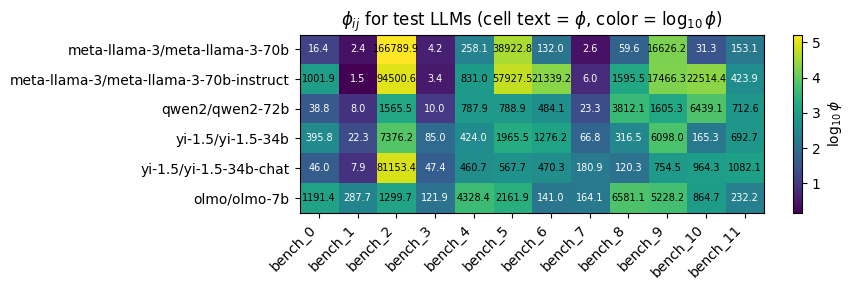

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Compute phi_ij with the SAME X_phi used at fit time ----
X_phi_np  = np.hstack((np.asarray(Xs[j][:, :3]), np.asarray(Ds[j])))   # (n, 3 + N_fam)
phi_int   = np.asarray(quad_models.phi_int)        # (J,)
phi_slope = np.asarray(quad_models.phi_slope)      # (p_phi, J) where p_phi = 3 + N_fam

log_phi_ij = X_phi_np @ phi_slope + phi_int        # (n, J)
phi_ij     = np.exp(log_phi_ij)                    # (n, J)

n, J   = phi_ij.shape
N_fam  = np.asarray(Ds[j]).shape[1]
p_cont = X_phi_np.shape[1] - N_fam                 # = 3

bench_names          = [f"bench_{k}" for k in range(J)]   # replace if you have names
cont_covariate_names = ['log(s)', 'log(t)', 'log(s)·log(t)'][:p_cont]

# ---- 2. Summary table ----
print(f"{'benchmark':<15} {'min':>10} {'q25':>10} {'median':>10} {'q75':>10} {'max':>10}")
for k in range(J):
    pk = phi_ij[:, k]
    print(f"{bench_names[k]:<15} "
          f"{pk.min():>10.3f} {np.quantile(pk, .25):>10.3f} "
          f"{np.median(pk):>10.3f} {np.quantile(pk, .75):>10.3f} "
          f"{pk.max():>10.3f}")

# ---- 3. Histogram of phi per benchmark ----
n_cols = 4
n_rows = int(np.ceil(J / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.3*n_rows))
axes = np.atleast_1d(axes).flatten()
for k in range(J):
    axes[k].hist(phi_ij[:, k], bins=30, edgecolor='black', alpha=0.7)
    axes[k].set_xscale('log')
    axes[k].set_title(bench_names[k], fontsize=10)
    axes[k].set_xlabel('phi'); axes[k].set_ylabel('count')
for k in range(J, len(axes)):
    axes[k].set_visible(False)
plt.suptitle('Distribution of estimated $\\phi_{ij}$ across training LLMs', y=1.02)
plt.tight_layout(); plt.show()

# ---- 4. phi vs continuous covariates only (family dummies are 0/1, skip) ----
fig, axes = plt.subplots(p_cont, J, figsize=(2*J, 2*p_cont), squeeze=False)
for c in range(p_cont):
    for k in range(J):
        ax = axes[c, k]
        ax.scatter(X_phi_np[:, c], phi_ij[:, k], s=10, alpha=0.4)
        ax.set_yscale('log')
        if c == 0:  ax.set_title(bench_names[k], fontsize=8)
        if k == 0:  ax.set_ylabel(cont_covariate_names[c], fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('$\\phi_{ij}$ vs continuous covariates (log y-axis)', y=1.02)
plt.tight_layout(); plt.show()

# ---- 5. Family-specific dispersion effects (the new part you just added) ----
# phi_slope[p_cont:, :] is the family log-multiplier on phi per benchmark
family_effects = phi_slope[p_cont:, :]            # (N_fam, J), log scale

# Replace with your real family-name list (must match column order of Ds[j])
try:
    fam_names_all = family_names
except NameError:
    fam_names_all = [f"fam_{l}" for l in range(N_fam)]

# Show top and bottom ~15 by average dispersion effect to keep the plot readable
mean_eff = family_effects.mean(axis=1)
top_k    = min(15, N_fam // 2)
top_idx  = np.argsort(mean_eff)[-top_k:][::-1]    # families that inflate phi most
bot_idx  = np.argsort(mean_eff)[:top_k]            # families that deflate phi most

vlim = np.abs(family_effects).max()
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, top_k*0.3)))
for ax, idx_set, title in zip(
        axes, [top_idx, bot_idx],
        ['Families with HIGHEST log-phi effect (=tighter fit)',
         'Families with LOWEST log-phi effect (=looser fit)']):
    im = ax.imshow(family_effects[idx_set], aspect='auto', cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim)
    ax.set_xticks(range(J)); ax.set_xticklabels(bench_names, rotation=45, ha='right')
    ax.set_yticks(range(len(idx_set)))
    ax.set_yticklabels([fam_names_all[l] for l in idx_set])
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label='log-phi family effect')
plt.tight_layout(); plt.show()

# ---- 6. Locate test LLMs ----
test_models = {'meta-llama-3':['meta-llama-3-70b', 'meta-llama-3-70b-instruct'],
               'qwen2'       :['qwen2-72b'],
               'yi-1.5'      :['yi-1.5-34b', 'yi-1.5-34b-chat'],
               'olmo'        :['olmo-7b']}

model_names = dfs[0]['model'].values
test_rows = []
for family, models in test_models.items():
    for m in models:
        hits = np.where(model_names == m)[0]
        if len(hits) == 0:
            print(f"  [warn] {m} not found in df[0].model")
            continue
        test_rows.append((family, m, int(hits[0])))

test_idx    = [r[2] for r in test_rows]
test_labels = [f"{r[0]}/{r[1]}" for r in test_rows]
phi_test    = phi_ij[test_idx]                    # (n_test, J)

# ---- 7. Printed table grouped by family ----
print(f"\n{'model':<45}" + "".join(f"{bn:>10}" for bn in bench_names))
print("-" * (45 + 10*J))
current_family = None
for (family, m, idx), row in zip(test_rows, phi_test):
    if family != current_family:
        print(f"[{family}]")
        current_family = family
    print(f"  {m:<43}" + "".join(f"{v:>10.3f}" for v in row))

# ---- 8. Heatmap of phi for the test LLMs ----
fig, ax = plt.subplots(figsize=(max(8, J*0.75), max(3, len(test_labels)*0.45)))
im = ax.imshow(np.log10(phi_test), aspect='auto', cmap='viridis')
ax.set_xticks(range(J)); ax.set_xticklabels(bench_names, rotation=45, ha='right')
ax.set_yticks(range(len(test_labels))); ax.set_yticklabels(test_labels)
ax.set_title(r'$\phi_{ij}$ for test LLMs (cell text = $\phi$, color = $\log_{10}\phi$)')
plt.colorbar(im, ax=ax, label=r'$\log_{10}\phi$')
mean_log = np.log10(phi_test).mean()
for i in range(len(test_labels)):
    for k in range(J):
        ax.text(k, i, f"{phi_test[i, k]:.1f}",
                ha='center', va='center',
                color='white' if np.log10(phi_test[i, k]) < mean_log else 'black',
                fontsize=7)
plt.tight_layout(); plt.show()

# ---- 9. Where test LLMs fall in training distribution ----
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.3*n_rows))
axes = np.atleast_1d(axes).flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(test_labels)))
for k in range(J):
    ax = axes[k]
    ax.hist(phi_ij[:, k], bins=30, color='lightgray', edgecolor='black', alpha=0.7)
    ax.set_xscale('log')
    ax.set_title(bench_names[k], fontsize=10)
    ax.set_xlabel('phi'); ax.set_ylabel('count')
    for li, v in enumerate(phi_test[:, k]):
        ax.axvline(v, color=colors[li], linewidth=1.5)
for k in range(J, len(axes)):
    axes[k].set_visible(False)
handles = [plt.Line2D([0], [0], color=c, label=l) for c, l in zip(colors, test_labels)]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=3, fontsize=8, frameon=False)
plt.suptitle(r'Test LLMs (colored lines) within training $\phi$ distribution', y=1.02)
plt.tight_layout(); plt.show()

In [13]:
model[4].sigma

array([[1.        , 0.2804375 , 0.37901706, 0.62543684],
       [0.2804375 , 0.99802715, 0.5713125 , 0.1010511 ],
       [0.37901706, 0.5713125 , 0.9871733 , 0.51799995],
       [0.62543684, 0.1010511 , 0.51799995, 0.9926462 ]], dtype=float32)

In [12]:
model[4].lambd[:,:]

array([[ 1.1529961 ,  0.        ,  0.        ,  0.        ,  0.22859503,
         0.26448226,  0.05851959, -0.04806397,  1.1538154 ,  0.10628762,
        -0.29935902, -0.6320246 ],
       [ 0.        ,  0.6055518 ,  0.        ,  0.        ,  0.09886394,
         0.1386228 ,  0.06032676,  0.58128554,  0.04085431, -0.09731114,
        -0.4194903 , -0.41326725],
       [ 0.        ,  0.        ,  0.50020725,  0.        , -0.03110188,
         0.03341148,  0.39299107, -0.26551434,  0.1532336 ,  0.5056969 ,
         0.10634232,  0.16876657],
       [ 0.        ,  0.        ,  0.        ,  1.1594214 ,  0.51790607,
         0.45433545,  0.07398126,  0.3224087 , -0.25833583, -0.00831536,
         1.6793092 ,  1.8438822 ]], dtype=float32)

### AIC

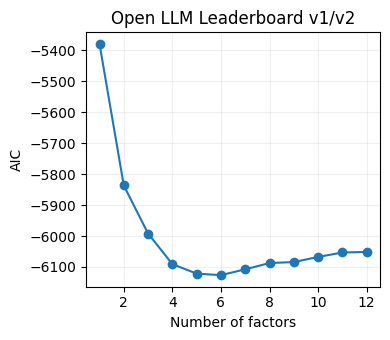

In [15]:
aic = [m.aic for m in models[0].values()]

fig, axes = plt.subplots(1, 1, figsize=(4, 3.5))

axes.plot(list(range(1,13)), aic, marker='o')
axes.set_title(names[0])
axes.set_xlabel('Number of factors')
axes.set_ylabel('AIC')
axes.grid(True,alpha=.2)

plt.tight_layout()
plt.savefig(f'plots/aic.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

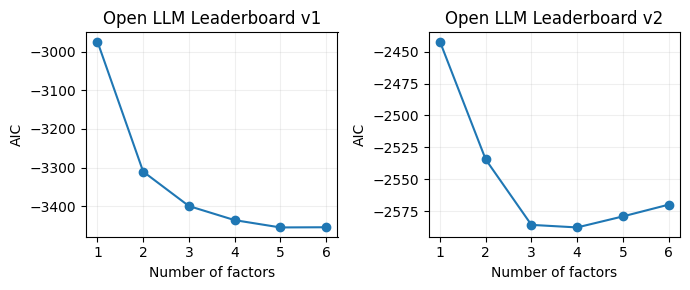

In [16]:
aic1 = [m.aic for m in models[1].values()]
aic2 = [m.aic for m in models[2].values()]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].plot(list(range(1,7)), aic1, marker='o')
axes[0].set_title(names[1])
axes[0].set_xlabel('Number of factors')
axes[0].set_ylabel('AIC')
axes[0].grid(True,alpha=.2)

axes[1].plot(list(range(1,7)), aic2, marker='o')
axes[1].set_title(names[2])
axes[1].set_xlabel('Number of factors')
axes[1].set_ylabel('AIC')
axes[1].grid(True,alpha=.2)

plt.tight_layout()
plt.savefig(f'plots/aic2.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Correlations and loadings

In [17]:
K_opt = {0:4,
         1:4,
         2:3}

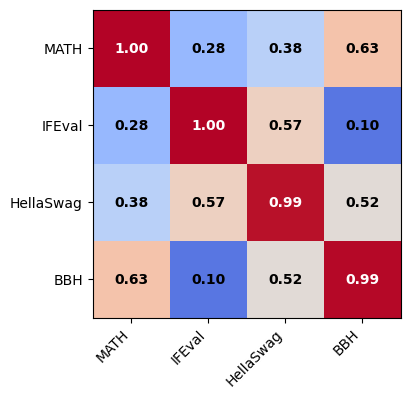

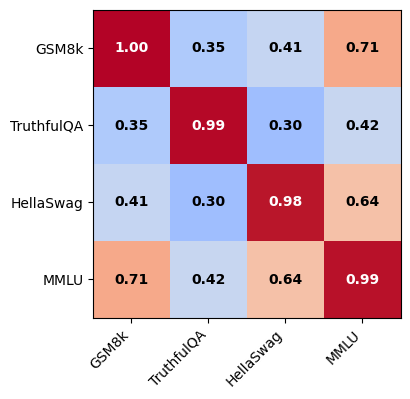

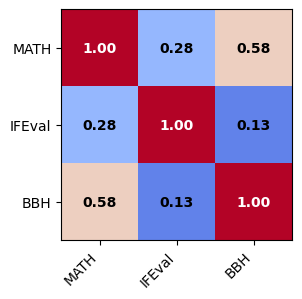

In [18]:
vmin=0
vmax=1
for j in Y_names.keys():

    k = K_opt[j]
    d = k
    model = models[j][k]
    Sigma = model.sigma
    factor_labels=[Y_names_tidy[s] for s in Y_names[j]][:k]
    
    plt.figure(figsize=(d,d))  # Set the figure size (width, height) in inches
    plt.imshow(Sigma, cmap=colormap, vmin=vmin, vmax=vmax)
    plt.xticks(np.arange(d), labels=factor_labels, rotation=45, ha="right")  # Set the x-tick labels
    plt.yticks(np.arange(d), labels=factor_labels, rotation=0, ha="right")  # Set the y-tick labels
    
    threshold = .8
    for i in range(len(Sigma)):
        for jj in range(len(Sigma.T)):
            value = Sigma[i, jj]
            color = "black" if value < threshold else "white"  # Conditional color
            text = plt.text(jj, i, f'{value:.2f}', size=10, ha="center", va="center", color=color, weight='bold')#
    
    plt.savefig(f'plots/skills-correlation_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
    plt.show()

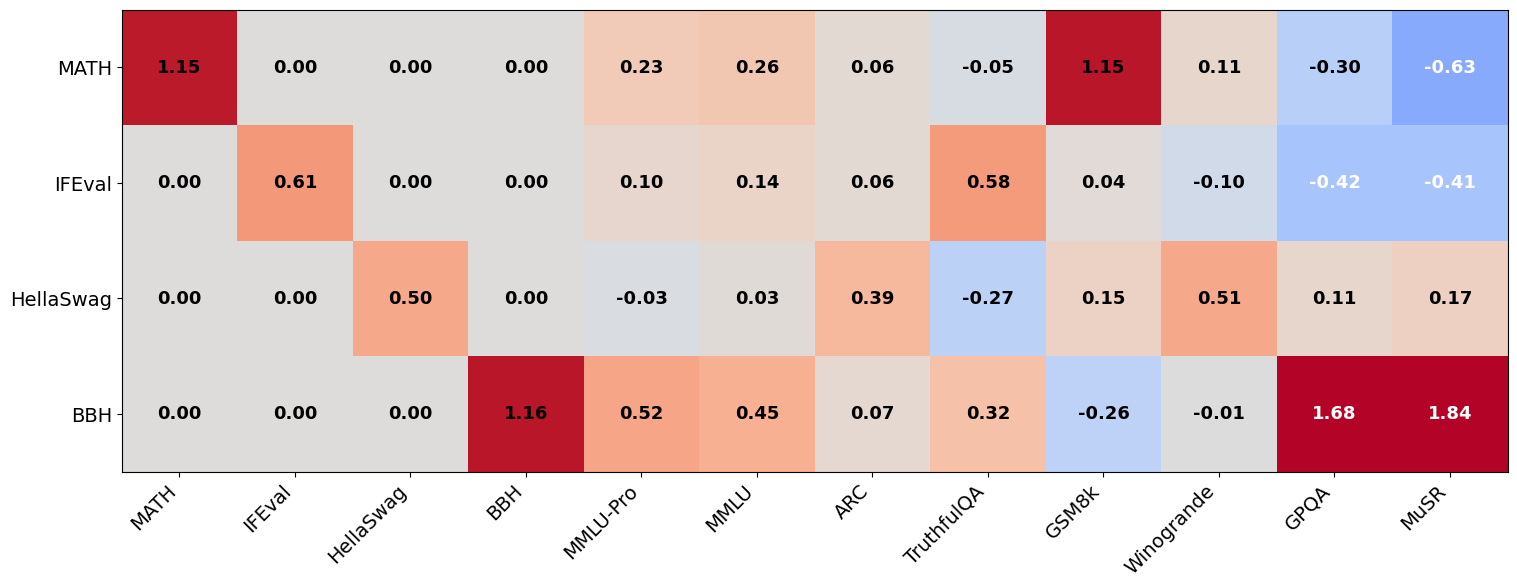

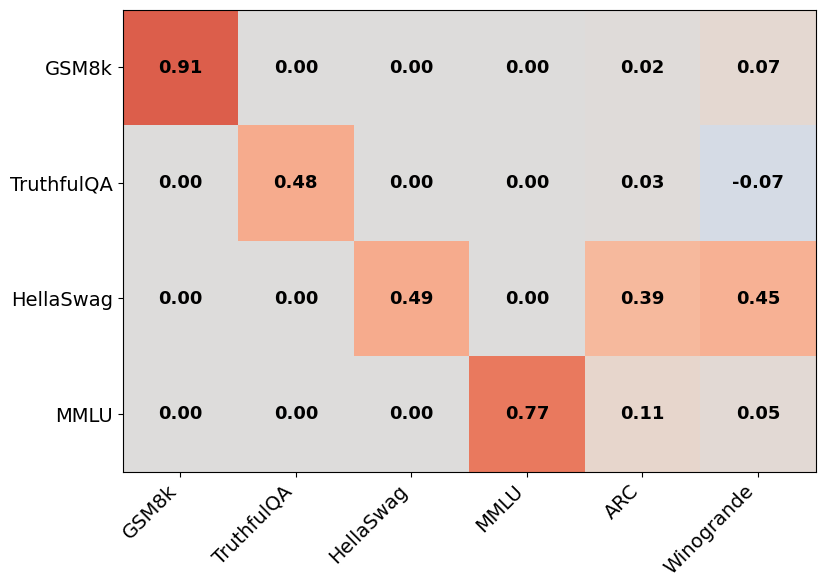

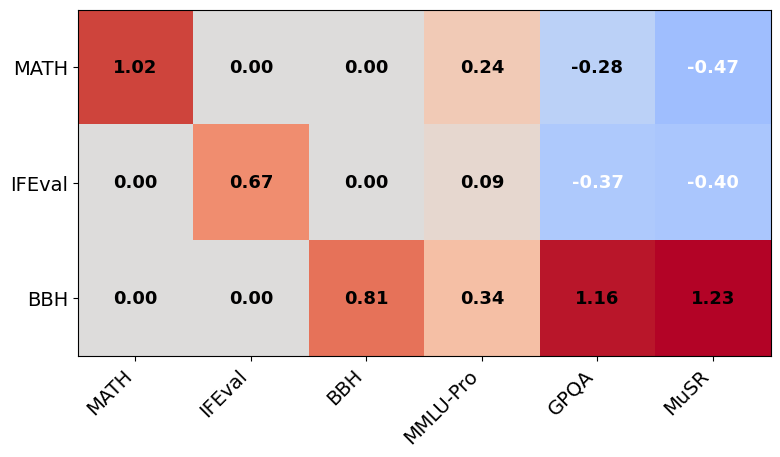

In [19]:
vmin=-1.2#None
vmax=1.2#None

for j in Y_names.keys():

    k = K_opt[j]
    model = models[j][k]
    L_rot = model.lambd
    
    plt.figure(figsize=((10/6)*L_rot.shape[1], (6/4)*k))  # Set the figure size (width, height) in inches
    plt.imshow(L_rot, cmap=colormap, vmin=vmin, vmax=vmax)
    plt.xticks(np.arange(len(Y_names[j])), labels=[Y_names_tidy[s] for s in Y_names[j]], size=fontsize+1, rotation=45, ha="right")  # Set the x-tick labels
    plt.yticks(np.arange(k), labels=[Y_names_tidy[s] for s in Y_names[j]][:k], size=fontsize+1, rotation=0, ha="right")  # Set the y-tick labels
    
    inter = [-.3,1.6]
    for i in range(len(L_rot)):
        for jj in range(len(L_rot.T)):
            value = L_rot[i, jj]
            color = "black" if value > inter[0] and  value < inter[1] else "white"  # Conditional color
            text = plt.text(jj, i, f'{value:.2f}', size=fontsize, ha="center", va="center", color=color, weight='bold')#

    plt.savefig(f'plots/loadings_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
    plt.show()

## Confidence intervals for beta

In [ ]:
Ss = {}
for j in tqdm(Y_names.keys()):
    Ss[j] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], models[j], K_opt[j])
    np.save("data/stes.npy",Ss)

  0%|          | 0/3 [00:00<?, ?it/s]


KeyboardInterrupt



In [20]:
Ss = np.load("data/stes.npy", allow_pickle=True).item()

In [21]:
labels = ['log(s)', 'log(t)', 'log(s)log(t)']

In [22]:
for j in range(3):
    print("\n\n")
    print(numpy_to_latex_table(models[j][K_opt[j]].beta/stds[j][:,None],
                         Ss[j][0][1]['beta_ste']/stds[j][:,None], float_format="%.3f", row_labels=labels, col_names=[f"Factor {f+1}" for f in range(K_opt[j])]))




\begin{table}[ht]
\centering
% Requires \usepackage{booktabs} and \usepackage{multirow}
\begin{tabular}{c c c c c}
\toprule
 & Factor 1 & Factor 2 & Factor 3 & Factor 4 \\
\midrule
\multirow{2}{*}{log(s)} & 0.432 & 0.190 & 0.840 & 0.656 \\
 & (0.065) & (0.054) & (0.055) & (0.079) \\
\midrule
\multirow{2}{*}{log(t)} & 0.774 & 0.324 & 0.384 & 0.445 \\
 & (0.101) & (0.087) & (0.085) & (0.115) \\
\midrule
\multirow{2}{*}{log(s)log(t)} & 0.026 & 0.154 & -0.039 & 0.010 \\
 & (0.032) & (0.034) & (0.016) & (0.041) \\
\bottomrule
\end{tabular}
\caption{Insert your caption here.}
\label{tab:insert_label_here}
\end{table}



\begin{table}[ht]
\centering
% Requires \usepackage{booktabs} and \usepackage{multirow}
\begin{tabular}{c c c c c}
\toprule
 & Factor 1 & Factor 2 & Factor 3 & Factor 4 \\
\midrule
\multirow{2}{*}{log(s)} & 0.449 & 0.082 & 0.865 & 0.642 \\
 & (0.074) & (0.064) & (0.065) & (0.101) \\
\midrule
\multirow{2}{*}{log(t)} & 0.889 & 0.253 & 0.389 & 0.801 \\
 & (0.148) & (0.149) & 

## Family comparison

In [23]:
j = 0
K = K_opt[j]

In [24]:
cov = np.load("data/stes.npy", allow_pickle=True).item()
cov = cov[j][0][0]['V']

beta = models[j][K].beta
b = models[j][K].b
phi = models[j][K].phi
lambd1, lambd2 = np.diag(models[j][K].lambd[:,:K]), models[j][K].lambd[:,K:]
sigma = models[j][K].sigma

In [25]:
family_names = np.array(pd.get_dummies(dfs[j].family).columns)

f1='yi-1.5'
f2='yi-1.5-chat'
fs = [np.argmax(family_names==f1), np.argmax(family_names==f2)]
fs

[np.int64(164), np.int64(165)]

In [57]:
alphas = {}

for fam_number in fs:
    betas, bs, phis, lambds, sigmas = SampleParams(beta, b, phi, lambd1, lambd2, sigma, cov)
    
    alphas[fam_number] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(SampleAlpha)(i, betas, lambds, bs, phis, sigmas, Ds[j], fam_number, Xs[j], Ys[j], Cs[j], K,
                              n_samples=1000, random_seed=fam_number)
        for i in range(len(betas))
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:  4.4min remaining:  4.7min
[Parallel(n_jobs=-1)]: Done  59 out of 100 | elapsed:  4.4min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  70 out of 100 | elapsed:  4.9min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  81 out of 100 | elapsed:  4.9min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  92 out of 100 | elapsed:  4.9min remaining:   25.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   31.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.0mi

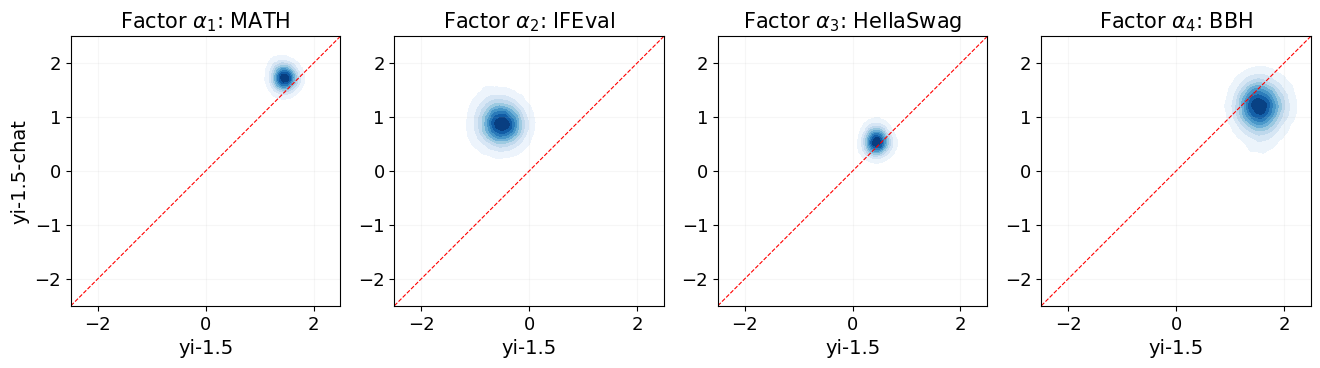

In [69]:
min_val = -2.5
max_val = 2.5

num_plots = K_opt[j]

# Create a row of subplots with shared tick positions
fig, axes = plt.subplots(1, num_plots, figsize=(4*num_plots, 3.5), 
                         sharex=True, sharey=True, squeeze=False)
axes = axes.flatten()  # Ensure we have a 1D array of axes

for k in range(num_plots):
    A = np.hstack((
        np.vstack(alphas[fs[0]])[:, k][:, None],
        np.vstack(alphas[fs[1]])[:, k][:, None]
    ))
    ax = axes[k]
    sns.kdeplot(x=A[:, 0], y=A[:, 1], cmap="Blues", fill=True, ax=ax)
    
    # Red dashed line
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=.8)
    
    # Set axis labels and title
    ax.set_xlabel(f"{f1}", fontsize=fontsize+1)
    ax.set_ylabel(f"{f2}", fontsize=fontsize+1)
    ax.set_title(f'Factor $\\alpha_{{{k+1}}}$: {[Y_names_tidy[s] for s in Y_names[j]][:K_opt[j]][k]}', 
                 fontsize=fontsize+2)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # Ensure tick labels are visible on each subplot
    ax.tick_params(axis='x', labelsize=fontsize, labelbottom=True)
    ax.tick_params(axis='y', labelsize=fontsize, labelleft=True)
    ax.grid(alpha=0.1)

# Adjust horizontal spacing between plots
plt.subplots_adjust(wspace=0.2)
plt.savefig(f'plots/comparing_factors_{j}.pdf', bbox_inches='tight', dpi=400, transparent=False)
plt.show()

## Prediction intervals

In [28]:
j = 0
K = K_opt[j]

In [ ]:
pred_models = {}
for fam in test_models.keys():
    train_idx = [m not in delete_models[fam] for m in dfs[j].model]
    
    pred_models[fam] = ScalingLaw(K)
    pred_models[fam].fit(Xs[j][train_idx],
                    Ys[j][train_idx],
                    Ds[j][train_idx],
                    Cs[j],
                    B = B,
                    lrs = lrs,
                    scheduler_factors = scheduler_factors,
                    reps = reps,
                    n_epochs = n_epochs,    
                    verbose = False,
                    device = device)
        
    np.save(f"models/pred_models.npy",pred_models)

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/5 [00:00<?, ?it/s]

/home/skunk/miniconda3/envs/arena/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Exception ignored in: <function tqdm.__del__ at 0x75591c1a6200>
Traceback (most recent call last):
  File "/home/skunk/miniconda3/envs/arena/lib/python3.12/site-packages/tqdm/std.py", line 1147, in __del__
    def __del__(self):

KeyboardInterrupt: 


In [30]:
pred_models = np.load(f"models/pred_models.npy", allow_pickle=True).item()

In [ ]:
pred_Ss = {}
j=0
for fam in tqdm(test_models.keys()):
    pred_Ss[fam] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], pred_models[fam], K)
    np.save("data/pred_stes.npy",pred_Ss)

In [32]:
pred_Ss = np.load("data/pred_stes.npy", allow_pickle=True).item()

In [33]:
test_models = {'meta-llama-3':['meta-llama-3-70b', 'meta-llama-3-70b-instruct'],
               'qwen2':['qwen2-72b'],
               'yi-1.5':['yi-1.5-34b', 'yi-1.5-34b-chat'],
               'olmo':['olmo-7b']}
decode_fam = {'meta-llama-3':'meta-llama-3',
              'meta-llama-3-instruct':'meta-llama-3',
              'qwen2':'qwen2',
              'yi-1.5':'yi-1.5',
              'yi-1.5-chat':'yi-1.5',
              'olmo':'olmo'}

In [34]:
family_names = np.array(pd.get_dummies(dfs[j].family).columns)

alphas, betas, bs, phis, lambds, sigmas = {}, {}, {}, {}, {}, {}

for llm in tqdm(np.hstack(list(test_models.values())).tolist()):
    llm_number = np.argmax(np.array(dfs[j].model)==llm)
    fam = dfs[j].iloc[llm_number].family
    fam_number = np.argmax(family_names==fam)
    
    cov = pred_Ss[decode_fam[fam]][0][0]['V']
    beta = pred_models[decode_fam[fam]].beta
    b = pred_models[decode_fam[fam]].b
    phi = pred_models[decode_fam[fam]].phi
    lambd1, lambd2 = np.diag(pred_models[decode_fam[fam]].lambd[:,:K]), pred_models[decode_fam[fam]].lambd[:,K:]
    sigma = pred_models[decode_fam[fam]].sigma
    
    betas[fam], bs[fam], phis[fam], lambds[fam], sigmas[fam] = SampleParams(beta, b, phi, lambd1, lambd2, sigma, cov)
        
    alphas[fam] = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(SampleAlpha)(i, betas[fam], lambds[fam], bs[fam], phis[fam], sigmas[fam], Ds[j], fam_number, Xs[j], Ys[j], Cs[j], K,
                              n_samples=1, random_seed=fam_number)
        for i in range(len(betas[fam]))
    )

  0%|          | 0/6 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done  96 out of 100 | elapsed:   20.4s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.4s
[Parallel(n_jo

In [35]:
sigmoid = torch.sigmoid
from torch.distributions import Beta

In [36]:
x_grid = np.linspace(.5,80,25)
m=1000

In [37]:
perc = {}
perc_grid = {}
XX = {}
YY = {}

for llm in tqdm(np.hstack(list(test_models.values())).tolist()):
    llm_number = np.argmax(np.array(dfs[j].model)==llm)
    fam = dfs[j].iloc[llm_number].family
    fam_number = np.argmax(family_names==fam)
    assert fam_number == np.argmax(Ds[j][llm_number])
    
    X = np.array(dfs[j].loc[:,['size','tokens']])[llm_number]
    Y = torch.tensor(Ys[j][llm_number])
    C = torch.tensor(Cs[j])
    D = torch.tensor(Ds[j])
    
    X_grid = x_grid[:,None]
    X_grid = np.log(np.hstack((X_grid,np.array(X_grid.shape[0]*[X[1]])[:,None])))
    X_grid = np.hstack((X_grid,(X_grid[:,0]*X_grid[:,1])[:,None]))
    X_grid = torch.tensor((X_grid-mus[j])/stds[j])
    
    X = np.log(X)
    X = np.hstack((X[None,:],(X[None,:][:,0]*X[None,:][:,1])[:,None]))
    X = torch.tensor((X-mus[j])/stds[j])

    XX[llm] = X.numpy()
    YY[llm] = Y.numpy()
    
    samples = []
    for t in range(len(betas[fam])):
        beta = torch.tensor(betas[fam][t])
        b = torch.tensor(bs[fam][t])
        phi = torch.tensor(phis[fam][t])
        lambd = torch.tensor(lambds[fam][t])
        alpha = torch.tensor(alphas[fam][t])
        mu = C+(1-C)*sigmoid(torch.clamp((X@beta+alpha)@lambd+b, min=-4.5, max=4.5))
        beta_dist = Beta(phi*mu, phi*(1-mu))
        samples.append(beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy())
    samples = np.vstack(samples)
    
    samples_grid = []
    for x in X_grid[:,None]:
        samples_grid.append([])
        for t in range(len(betas[fam])):
            beta = torch.tensor(betas[fam][t])
            b = torch.tensor(bs[fam][t])
            phi = torch.tensor(phis[fam][t])
            lambd = torch.tensor(lambds[fam][t])
            alpha = torch.tensor(alphas[fam][t])
            mu = C+(1-C)*sigmoid(torch.clamp((x@beta+alpha)@lambd+b, min=-4.5, max=4.5))
            beta_dist = Beta(phi*mu, phi*(1-mu))
            samples_grid[-1].append(beta_dist.sample(sample_shape=(m,)).squeeze().cpu().numpy())
        samples_grid[-1] = np.vstack(samples_grid[-1])
    samples_grid = np.array(samples_grid)
    
    perc[llm] = np.percentile(samples, q=[2.5,97.5,50], axis=0)
    perc_grid[llm] = np.percentile(samples_grid, q=[2.5,97.5,50], axis=1)

  0%|          | 0/6 [00:00<?, ?it/s]

In [46]:
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_scaling_panels(
    Y_names, j, test_models, x_grid, perc_grid, mus, stds, XX, YY,
    *,
    ncols=3,
    figsize=(10, 12),
    dpi=300,
    out_path="scaling_panels.png",
    ylims=(0.0, 1.0),
    left_ylabel="score",
    bottom_xlabel=r"# weights ($10^9$)",
    title_size=11,
    label_size=10,
    tick_size=9,
    legend_ncols=3,
    label_map=None,          # e.g., {"yi-1.5-34b-chat":"yi-1.5-34b-chat"}
    linestyle_map=None       # e.g., {"qwen2-72b":"--","yi-1.5-34b": "-","yi-1.5-34b-chat": ":"}
):
    """
    Creates a K-panel figure (K = len(Y_names[j])) with one subplot per task.
    For each model m, it plots:
      - median curve: perc_grid[m][2][:, k]
      - shaded band:  perc_grid[m][0][:, k] .. perc_grid[m][1][:, k]
      - scatter:      (exp(mus[j] + stds[j] * XX[m]), YY[m][k])

    Colors are consistent per model across all artists.
    """
    if label_map is None:
        label_map = {}
    if linestyle_map is None:
        linestyle_map = {}

    # ---- Collect models in your existing order (no duplicates) ----
    model_list = []
    for v in test_models.values():
        model_list.extend(v)
    models = list(dict.fromkeys(model_list))

    # ---- Assign stable colors (prefer tab10 if available; fallback to C0..C9) ----
    try:
        tab10 = mpl.colormaps["tab10"]          # Matplotlib ≥ 3.6
        colors = {m: tab10(i % 10) for i, m in enumerate(models)}
    except Exception:
        colors = {m: f"C{i % 10}" for i, m in enumerate(models)}

    # ---- Build the subplot grid ----
    n_tasks = len(Y_names[j])
    nrows = math.ceil(n_tasks / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for k in range(n_tasks):
        ax = axes[k]
        ax.set_ylim(*ylims)
        ax.set_title(Y_names[j][k], fontsize=title_size)

        for m in models:
            col = colors[m]
            ls = linestyle_map.get(m, "--")

            # Curves and band
            y_med = np.asarray(perc_grid[m][2][:, k])
            y_lo  = np.asarray(perc_grid[m][0][:, k])
            y_hi  = np.asarray(perc_grid[m][1][:, k])

            ax.plot(x_grid, y_med, linestyle=ls, linewidth=1, color=col, label=label_map.get(m, m))
            ax.fill_between(x_grid, y_lo, y_hi, color=col, alpha=0.1, linewidth=0)

            # Scatter point at evaluated size
            x_scat = float(np.ravel(np.exp(mus[j] + stds[j] * XX[m]))[0])
            y_scat = float(YY[m][k])
            ax.scatter(x_scat, y_scat, s=28, color=col, edgecolor="none", zorder=3)

        # Only left column gets y-label; only bottom row gets x-label
        row_idx = k // ncols
        col_idx = k % ncols
        if col_idx == 0:
            ax.set_ylabel(left_ylabel, fontsize=label_size)
        else:
            ax.tick_params(axis="y", labelleft=False)

        if row_idx == nrows - 1:
            ax.set_xlabel(bottom_xlabel, fontsize=label_size)
        else:
            ax.tick_params(axis="x", labelbottom=False)

        ax.tick_params(labelsize=tick_size)

    # Hide any unused axes
    for k in range(n_tasks, len(axes)):
        axes[k].axis("off")

    # ---- Shared legend (one entry per model) ----
    legend_handles = [
        Line2D([0], [0],
               color=colors[m],
               linestyle=linestyle_map.get(m, "-"),
               linewidth=2,
               label=label_map.get(m, m))
        for m in models
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=min(legend_ncols, len(models)),
        fontsize=label_size,
        bbox_to_anchor=(0.5, -0.01)
    )

    # Room for legend + save
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved figure to: {out_path}")


# ---- Usage (uncomment once your variables exist) ----
plot_scaling_panels(
     {j: [Y_names_tidy[s] for s in Y_names[j]]}, j, test_models, x_grid, perc_grid, mus, stds, XX, YY,
     out_path="plots/scaling_panels.png",
     # Optional styling:
     # label_map={"qwen2-72b":"qwen2-72b", "yi-1.5-34b":"yi-1.5-34b", "yi-1.5-34b-chat":"yi-1.5-34b-chat"},
     # linestyle_map={"qwen2-72b":"--", "yi-1.5-34b":"-", "yi-1.5-34b-chat":":"},
)


Saved figure to: plots/scaling_panels.png


## Optimal scaling

In [437]:
import numpy as np

def make_joint_latex_table(
    t1, t2, t3, t4,
    group_names=[Y_names_tidy[y] for y in Y_names[j][:K_opt[j]]],
    caption="Optimal allocation across skills for various compute budgets.",
    label="tab:opt_full",
    flops_header=r"\textbf{FLOPs (1e19)",
    inner_headers=(r"\textbf{Params (B)}", r"\textbf{Tokens (T)}"),
    decimals=2,
):
    """
    Merge four (n,3) arrays [FLOPs, Params, Tokens] into one LaTeX table:
    1 shared FLOPs column + 2 columns per table = 9 columns total.
    """

    tables = [np.asarray(t, dtype=float) for t in (t1, t2, t3, t4)]
    nrows = tables[0].shape[0]

    # Validate shapes
    for i, t in enumerate(tables, 1):
        if t.ndim != 2 or t.shape[1] != 3:
            raise ValueError(f"Table {i} must have shape (n, 3): [FLOPs, Params, Tokens].")
        if t.shape[0] != nrows:
            raise ValueError("All tables must have the same number of rows (same FLOPs grid).")

    # Check FLOPs column alignment
    base_flops = tables[0][:, 0]
    for i in range(1, 4):
        if not np.allclose(base_flops, tables[i][:, 0], rtol=0, atol=1e-9):
            raise ValueError("First column (FLOPs) must match across all four tables.")

    # Formatting helpers
    fmt = f"{{:.{decimals}f}}".format

    def _tex_escape(s: str) -> str:
        return (s.replace("&", r"\&")
                 .replace("%", r"\%")
                 .replace("$", r"\$")
                 .replace("#", r"\#")
                 .replace("_", r"\_")
                 .replace("{", r"\{")
                 .replace("}", r"\}")
                 .replace("~", r"\textasciitilde{}")
                 .replace("^", r"\textasciicircum{}"))

    gnames = [_tex_escape(str(x)) for x in group_names]
    ih1, ih2 = inner_headers

    # Column alignment: c | cc | cc | cc | cc
    align = "c|" + "cc|" * 3 + "cc"

    # Build header lines (use only plain r-strings when no interpolation is needed)
    group_parts = []
    for k, name in enumerate(gnames):
        bar = "|" if k < len(gnames) - 1 else ""
        group_parts.append(rf"\multicolumn{{2}}{{c{bar}}}{{\textbf{{{name}}}}}")
    header_top = rf"{flops_header} & " + " & ".join(group_parts) + r" \\"
    header_sub = " & " + " & ".join([rf"{ih1} & {ih2}"] * 4) + r" \\"

    # Body rows
    body_lines = []
    for r in range(nrows):
        row = [fmt(base_flops[r])]
        for t in tables:
            row.append(fmt(t[r, 1]))  # Params
            row.append(fmt(t[r, 2]))  # Tokens
        body_lines.append(" & ".join(row) + r" \\")

    # Assemble LaTeX table
    latex = [
        r"\begin{table}[h!]",
        r"\centering",
        r"\footnotesize",
        rf"\begin{{tabular}}{{{align}}}",  # <-- doubled braces around 'tabular'
        r"\toprule",
        header_top,
        header_sub,
        r"\midrule",
        *body_lines,
        r"\bottomrule",
        r"\end{tabular}",
        rf"\caption{{{_tex_escape(caption)}}}",
        rf"\label{{{_tex_escape(label)}}}",
        r"\end{table}",
    ]
    return "\n".join(latex)

In [436]:
j=0

In [386]:
X = stds[j]*Xs[j]+mus[j]

In [399]:
Cs = [X.min(0)[:-1].sum(-1),X.max(0)[:-1].sum(-1)]
Cs = np.linspace(Cs[0], Cs[1], 10)

In [423]:
argmaxs = {}
for k in range(K_opt[j]):
    argmaxs[k] = []
    beta = models[j][K_opt[j]].beta[:,k]/stds[j]
    for c in Cs:
        
        def g(u,c):
            return -beta[2]*u**2 + (beta[0]-beta[1]+beta[2]*c)*u
        
        U = np.linspace(max(c-X.max(0)[1],X.min(0)[0]), min(c-X.min(0)[1],X.max(0)[0]), 1000)
        assert U[0]<=U[1]
        argmax_u = U[np.argmax([g(u,c) for u in U])]
        argmax_v = c - argmax_u
    
        argmaxs[k].append([np.exp(argmax_u), np.exp(argmax_v)])
    argmaxs[k] = np.array(argmaxs[k])
    argmaxs[k] = np.hstack((100*6*np.prod(argmaxs[k], -1)[:,None], argmaxs[k]))

In [438]:
print(make_joint_latex_table(argmaxs[0], argmaxs[1], argmaxs[2], argmaxs[3]))

\begin{table}[h!]
\centering
\footnotesize
\begin{tabular}{c|cc|cc|cc|cc}
\toprule
\textbf{FLOPs (1e19) & \multicolumn{2}{c|}{\textbf{MATH}} & \multicolumn{2}{c|}{\textbf{IFEval}} & \multicolumn{2}{c|}{\textbf{HellaSwag}} & \multicolumn{2}{c}{\textbf{BBH}} \\
 & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} & \textbf{Params (B)} & \textbf{Tokens (T)} \\
\midrule
6.30 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 & 0.07 & 0.15 \\
25.15 & 0.07 & 0.60 & 0.13 & 0.32 & 0.28 & 0.15 & 0.28 & 0.15 \\
100.37 & 0.07 & 2.39 & 0.26 & 0.63 & 1.12 & 0.15 & 1.12 & 0.15 \\
400.62 & 0.07 & 9.54 & 0.53 & 1.27 & 4.45 & 0.15 & 4.45 & 0.15 \\
1599.05 & 0.18 & 15.00 & 1.06 & 2.52 & 17.77 & 0.15 & 17.77 & 0.15 \\
6382.53 & 0.71 & 15.00 & 2.10 & 5.05 & 70.92 & 0.15 & 70.92 & 0.15 \\
25475.55 & 2.83 & 15.00 & 4.22 & 10.06 & 180.00 & 0.24 & 180.00 & 0.24 \\
101684.33 & 11.30 & 15.00 & 11.30 & 15.00 & 180.00 & 0.94 & 180.00 & 0.94 \\